# PhasePhyto: Physics-Informed Differentiable Phase Congruency for Cross-Domain Botanical Visual Recognition

This notebook implements the complete **PhasePhyto** framework -- a three-stream hybrid architecture that fuses:

1. **Phase Congruency Stream** -- 24 Log-Gabor filters (6 orientations x 4 scales) extract illumination-invariant structural maps
2. **ViT Semantic Backbone** -- `vit_base_patch16_224` extracts high-level semantic features  
3. **Illumination-Normalised Stream** -- CIELAB + CLAHE on luminance channel

These are fused via **cross-attention** where structural tokens (Q) attend to semantic tokens (K,V).

**Key property**: `PC(image) = PC(image * k)` for any `k > 0` -- mathematical illumination invariance.

---

**Use Case**: Plant Disease Detection (PlantVillage -> PlantDoc lab-to-field domain shift)

**Runtime**: Colab T4 GPU (~15GB VRAM)

## 0. Setup & Installation

In [1]:
# Install dependencies
# Colab already includes torch/torchvision/Pillow in the standard GPU runtime.
# Install the project-specific packages used by training, evaluation, and plots.
!pip install -q timm opencv-python-headless scikit-learn matplotlib seaborn tqdm pyyaml


In [2]:
import os
import json
import math
import random
from pathlib import Path
from typing import Any

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import GradScaler, autocast
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm.auto import tqdm
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import timm

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB


In [3]:
# Reproducibility
SEED = 42

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

In [4]:
!nvidia-smi
print("DEVICE:", DEVICE)

Mon Apr 20 18:16:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Configuration

In [5]:
# ============================================================
# CONFIGURATION - Edit these to match your setup
# ============================================================

CONFIG = {
    # Model
    "backbone_name": "vit_base_patch16_224",
    "fusion_dim": 256,
    "pc_scales": 4,
    "pc_orientations": 6,
    "num_heads": 4,
    "dropout": 0.1,
    "image_size": 224,

    # Training
    "lr": 5e-5,
    "weight_decay": 1e-2,
    "epochs": 20,
    "warmup_epochs": 3,
    "batch_size": 16,
    "grad_clip": 1.0,
    "patience": 8,

    # --- OOD-generalization knobs ---
    "label_smoothing": 0.1,
    "backbone_lr_mult": 0.1,
    "use_ema": True,
    "ema_decay": 0.999,
    "use_tta": True,
    "use_randaugment": True,
    "randaugment_n": 2,
    "randaugment_m": 9,
    "random_erasing_p": 0.25,
    "aux_pc_weight": 0.2,
    "bg_replace_p": 0.5,
    "bg_saturation_thresh": 40,
    "use_sam": True,
    "sam_rho": 0.05,
    "use_tent": True,
    "tent_steps": 20,
    "tent_lr": 1e-3,

    # --- OOD foreground segmentation (Phase 8) ---
    # HSV-saturation leaf foreground mask. When "hsv"/"hsv_blur", pixels with
    # low saturation (background, lab gray, shadow) are flattened/blurred so
    # the PC stream does not compute phase structure over clutter. Applied to
    # BOTH train and val transforms, so target (PlantDoc) eval also benefits.
    "leaf_mask_mode": "off",          # {"off","hsv","hsv_blur"}
    "leaf_mask_sat_thresh": 40,       # min HSV saturation to count as leaf
    "leaf_mask_blur_sigma": 1.5,      # gaussian sigma when mode == "hsv_blur"

    # --- Diagnostic training hooks (Phase 8) ---
    # checkpoint_every > 0: snapshot model every N epochs to
    #   runs/<ts>/checkpoints/epoch_<N>.pt so we can post-hoc pick the
    #   best-transferring epoch rather than trusting source val F1.
    # target_snapshot_every > 0: run target-domain eval every N epochs during
    #   training so the OOD trajectory is visible, not just the final number.
    "checkpoint_every": 0,
    "target_snapshot_every": 0,

    # --- Pseudo-label self-training (Phase 7.1.b) ---
    # After main training, predict on target with no grad and no aug. Keep
    # samples where max-softmax-prob >= threshold, fine-tune on (source +
    # pseudo target) for N epochs at lr * lr_mult. One round only (not
    # iterative / not FixMatch-style). Off by default; turn on when ready to
    # add target-side gradient to the training signal.
    "use_pseudo_label": False,
    "pseudo_label_threshold": 0.9,
    "pseudo_label_epochs": 5,
    "pseudo_label_lr_mult": 0.1,
    "pseudo_label_min_samples": 50,

    # --- Ablation (Phase 7.1 roadmap item) ---
    # "full"          : PC stream + ViT backbone + cross-attention fusion (default)
    # "pc_only"       : zero-out semantic tokens; classify from structural + illum
    # "backbone_only" : zero-out structural tokens; classify from semantic + illum
    # "no_fusion"     : compute both streams, skip cross-attention, mean-pool concat
    "ablation": "full",

    # Data/import paths
    "use_synthetic": True,
    "data_root": "/content/data",
    "plantvillage_dir": "",
    "plantdoc_dir": "",
    "num_workers": 0,

    # Pipeline/storage backend
    "storage_backend": "drive",
    "drive_project_dir": "/content/drive/MyDrive/PhasePhyto",
    "colab_project_dir": "/content/phasephyto_runs",
    "external_ssd_project_dir": "/content/ssd/PhasePhyto",
    "run_name": None,
    "download_outputs_at_end": False,
}

CONFIG["use_synthetic"] = False
CONFIG["plantvillage_dir"] = "/content/data/plantvillage"
CONFIG["plantdoc_dir"] = "/content/data/plantdoc"
CONFIG["storage_backend"] = "drive"
CONFIG["drive_project_dir"] = "/content/drive/MyDrive/PhasePhyto"
CONFIG["num_workers"] = 0


print("Configuration loaded.")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")


Configuration loaded.
  backbone_name: vit_base_patch16_224
  fusion_dim: 256
  pc_scales: 4
  pc_orientations: 6
  num_heads: 4
  dropout: 0.1
  image_size: 224
  lr: 5e-05
  weight_decay: 0.01
  epochs: 20
  warmup_epochs: 3
  batch_size: 16
  grad_clip: 1.0
  patience: 8
  label_smoothing: 0.1
  backbone_lr_mult: 0.1
  use_ema: True
  ema_decay: 0.999
  use_tta: True
  use_randaugment: True
  randaugment_n: 2
  randaugment_m: 9
  random_erasing_p: 0.25
  aux_pc_weight: 0.2
  bg_replace_p: 0.5
  bg_saturation_thresh: 40
  use_sam: True
  sam_rho: 0.05
  use_tent: True
  tent_steps: 20
  tent_lr: 0.001
  ablation: full
  use_synthetic: False
  data_root: /content/data
  plantvillage_dir: /content/data/plantvillage
  plantdoc_dir: /content/data/plantdoc
  num_workers: 0
  storage_backend: drive
  drive_project_dir: /content/drive/MyDrive/PhasePhyto
  colab_project_dir: /content/phasephyto_runs
  external_ssd_project_dir: /content/ssd/PhasePhyto
  run_name: None
  download_outputs_at_en

In [6]:
# Model
# CONFIG["backbone_name"] = "vit_base_patch16_224"
# CONFIG["fusion_dim"] = 256
# CONFIG["pc_scales"] = 4
# CONFIG["pc_orientations"] = 6
# CONFIG["num_heads"] = 4
# CONFIG["dropout"] = 0.15


CONFIG["pc_orientations"] = 8
CONFIG["dropout"] = 0.15
CONFIG["num_heads"] = 8


In [7]:
# Training-schedule overrides for the domain-shift run.

CONFIG["epochs"] = 15
CONFIG["patience"] = 0          # disable early stopping; use full budget + EMA
CONFIG["warmup_epochs"] = 2
CONFIG["batch_size"] = 16       # reduce to 8 if OOM (SAM disables AMP)
CONFIG["lr"] = 3e-4
CONFIG["backbone_lr_mult"] = 0.1
CONFIG["weight_decay"] = 5e-2
CONFIG["dropout"] = 0.2
CONFIG["grad_clip"] = 1.0
CONFIG["pc_orientations"] = 8
CONFIG["num_heads"] = 8
CONFIG["label_smoothing"] = 0.1
CONFIG["use_ema"] = True
CONFIG["ema_decay"] = 0.999
CONFIG["use_tta"] = True
CONFIG["use_randaugment"] = True
CONFIG["random_erasing_p"] = 0.25
CONFIG["aux_pc_weight"] = 0.2
CONFIG["bg_replace_p"] = 0.5
CONFIG["use_sam"] = True
CONFIG["sam_rho"] = 0.05
CONFIG["use_tent"] = True
CONFIG["tent_steps"] = 20
CONFIG["tent_lr"] = 1e-3

# ----- Phase 7.1.a: foreground segmentation + training diagnostics -----
# Enabled as of v0.1.16: leaf mask gates non-leaf pixels so PC stream does
# not fit source background structure (direct treatment for the pc_only
# target F1=0.08 collapse). Applied to train AND val/target transforms.
# Set leaf_mask_mode = "off" to reproduce the pre-v0.1.16 behaviour.
CONFIG["leaf_mask_mode"] = "hsv"             # {"off","hsv","hsv_blur"}
CONFIG["leaf_mask_sat_thresh"] = 40
CONFIG["leaf_mask_blur_sigma"] = 1.5

# Training diagnostics. Periodic checkpoint lets us post-hoc pick the epoch
# that transferred best (best-val-F1 is a poor target proxy when source
# saturates early). Target snapshot makes the OOD trajectory visible.
CONFIG["checkpoint_every"] = 3               # save ckpt every 3 epochs
CONFIG["target_snapshot_every"] = 3          # eval target every 3 epochs

# ----- Phase 7.1.b: pseudo-label self-training -----
# After main training, self-train one round on high-confidence target
# predictions. Skip by setting use_pseudo_label = False. Bigger threshold
# -> fewer, cleaner pseudo-labels; smaller -> more gradient but more noise.
CONFIG["use_pseudo_label"] = True
CONFIG["pseudo_label_threshold"] = 0.9
CONFIG["pseudo_label_epochs"] = 5
CONFIG["pseudo_label_lr_mult"] = 0.1         # of CONFIG["lr"]
CONFIG["pseudo_label_min_samples"] = 50      # skip phase if fewer than this

# ----- Ablation (Phase 7.1 roadmap) -----
# Change this to "pc_only" / "backbone_only" / "no_fusion" and re-run the
# notebook to produce the ablation numbers. Each ablation auto-suffixes the
# run_name so artifacts land in separate run directories and do not overwrite.
CONFIG["ablation"] = "full"     # {"full","pc_only","backbone_only","no_fusion"}

# aux_pc_head is PC-stream-only; silence its loss when PC is disabled.
if CONFIG["ablation"] == "backbone_only":
    CONFIG["aux_pc_weight"] = 0.0


In [8]:
backend = CONFIG.get("storage_backend", "drive").lower()

if backend == "drive":
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
        OUTPUT_ROOT = Path(CONFIG["drive_project_dir"])
        print(f"Google Drive mounted. Output root: {OUTPUT_ROOT}")
    except Exception as exc:
        print(f"Drive mount failed ({exc}); falling back to Colab local SSD.")
        backend = "colab_ssd"
        OUTPUT_ROOT = Path(CONFIG["colab_project_dir"])
elif backend == "external_ssd":
    OUTPUT_ROOT = Path(CONFIG["external_ssd_project_dir"])
    if not OUTPUT_ROOT.parent.exists():
        print(f"WARNING: external SSD parent does not exist yet: {OUTPUT_ROOT.parent}")
    print(f"Using external/hooked SSD output root: {OUTPUT_ROOT}")
elif backend == "colab_ssd":
    OUTPUT_ROOT = Path(CONFIG["colab_project_dir"])
    print(f"Using Colab local SSD output root: {OUTPUT_ROOT}")
else:
    raise ValueError(f"Unknown storage_backend={backend!r}; use drive, colab_ssd, or external_ssd")




Mounted at /content/drive
Google Drive mounted. Output root: /content/drive/MyDrive/PhasePhyto


In [9]:
!rm -rf /content/data/plantvillage /content/data/plantdoc
!mkdir -p /content/data/plantvillage
!mkdir -p /content/data/plantdoc

!tar -xf /content/drive/MyDrive/PhasePhyto/data/archives/plantvillage.tar -C /content/data/plantvillage

!tar -xf /content/drive/MyDrive/PhasePhyto/data/archives/plantdoc.tar -C /content/data/plantdoc

# Then:

CONFIG["plantvillage_dir"] = "/content/data/plantvillage"
CONFIG["plantdoc_dir"] = "/content/data/plantdoc"

In [10]:
from pathlib import Path

print("PV exists:", Path(CONFIG["plantvillage_dir"]).exists())
print("PD exists:", Path(CONFIG["plantdoc_dir"]).exists())

print("PV class dirs:", len([p for p in
Path(CONFIG["plantvillage_dir"]).iterdir() if p.is_dir()]))
print("PD dirs:", [p.name for p in Path(CONFIG["plantdoc_dir"]).iterdir() if
p.is_dir()][:10])

PV exists: True
PD exists: True
PV class dirs: 25
PD dirs: ['train', 'test']


## 1.1 Pipeline Segmentation & Storage Routing

All generated artifacts are written under one run directory. Set
`CONFIG["storage_backend"]` to `"drive"`, `"colab_ssd"`, or `"external_ssd"`
to route checkpoints, plots, metrics, and manifests to Google Drive, fast local
Colab storage, or a mounted/hooked SSD path.


In [12]:
# ============================================================
# PIPELINE SEGMENTATION + STORAGE-BACKEND ARTIFACT ROUTING
# ============================================================
from datetime import datetime


_ts = datetime.now().strftime("%Y%m%d-%H%M%S")
_ablation = CONFIG.get("ablation", "full")
RUN_NAME = CONFIG["run_name"] or f"{_ts}_{_ablation}"
RUN_DIR = OUTPUT_ROOT / "runs" / RUN_NAME
CHECKPOINT_DIR = RUN_DIR / "checkpoints"
PLOTS_DIR = RUN_DIR / "plots"
RESULTS_DIR = RUN_DIR / "results"
MANIFEST_PATH = RUN_DIR / "run_manifest.json"

for directory in [CHECKPOINT_DIR, PLOTS_DIR, RESULTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

ARTIFACTS = {
    "storage_backend": backend,
    "run_dir": str(RUN_DIR),
    "checkpoints": str(CHECKPOINT_DIR),
    "plots": str(PLOTS_DIR),
    "results": str(RESULTS_DIR),
    "ablation": _ablation,
}

print("Pipeline stages:")
for stage in [
    "0 setup + storage routing",
    "1 data import / synthetic generation",
    "2 model build + physics checks",
    "3 PhasePhyto training",
    "4 source/target evaluation",
    "5 baseline training",
    "6 comparison + visualizations",
    "7 artifact manifest",
]:
    print(f"  - {stage}")

print(f"\nAblation: {_ablation}")
print("\nArtifact directories:")
for name, value in ARTIFACTS.items():
    print(f"  {name}: {value}")


Pipeline stages:
  - 0 setup + storage routing
  - 1 data import / synthetic generation
  - 2 model build + physics checks
  - 3 PhasePhyto training
  - 4 source/target evaluation
  - 5 baseline training
  - 6 comparison + visualizations
  - 7 artifact manifest

Ablation: full

Artifact directories:
  storage_backend: drive
  run_dir: /content/drive/MyDrive/PhasePhyto/runs/20260420-181750_full
  checkpoints: /content/drive/MyDrive/PhasePhyto/runs/20260420-181750_full/checkpoints
  plots: /content/drive/MyDrive/PhasePhyto/runs/20260420-181750_full/plots
  results: /content/drive/MyDrive/PhasePhyto/runs/20260420-181750_full/results
  ablation: full


In [13]:
from pathlib import Path

print("use_synthetic:", CONFIG.get("use_synthetic"))
print("plantvillage_dir:", CONFIG.get("plantvillage_dir"))
print("plantdoc_dir:", CONFIG.get("plantdoc_dir"))
print("storage_backend:", CONFIG.get("storage_backend"))
print("run dir:", RUN_DIR)

PV = Path(CONFIG["plantvillage_dir"])
PD = Path(CONFIG["plantdoc_dir"])

print("\nPV exists:", PV.exists())
print("PD exists:", PD.exists())

if PV.exists():
    print("PV files:", sum(1 for p in PV.rglob("*") if p.is_file()))
    print("PV class dirs:", len([p for p in PV.iterdir() if p.is_dir()]))

if PD.exists():
    print("PD files:", sum(1 for p in PD.rglob("*") if p.is_file()))
    print("PD top dirs:", [p.name for p in PD.iterdir() if p.is_dir()][:30])


use_synthetic: False
plantvillage_dir: /content/data/plantvillage
plantdoc_dir: /content/data/plantdoc
storage_backend: drive
run dir: /content/drive/MyDrive/PhasePhyto/runs/20260420-181750_full

PV exists: True
PD exists: True
PV files: 28996
PV class dirs: 25
PD files: 2578
PD top dirs: ['train', 'test']


## 2. Data: PlantVillage & PlantDoc

**PlantVillage** (source domain): 54,305 lab images, 38 classes  
**PlantDoc** (target domain): 2,598 field images, 27 classes  

We train on PlantVillage and evaluate zero-shot on PlantDoc.

In [14]:
# Download PlantVillage dataset from Kaggle
# Option A: Upload your kaggle.json and use the Kaggle API
# Option B: Mount Google Drive with pre-downloaded data
# Option C: Use synthetic data to verify the full training/evaluation pipeline

DATA_ROOT = Path(CONFIG["data_root"])
DATA_ROOT.mkdir(parents=True, exist_ok=True)

PLANTVILLAGE_DIR = (
    Path(CONFIG["plantvillage_dir"])
    if CONFIG.get("plantvillage_dir")
    else DATA_ROOT / "plantvillage"
)
PLANTDOC_DIR = (
    Path(CONFIG["plantdoc_dir"])
    if CONFIG.get("plantdoc_dir")
    else DATA_ROOT / "plantdoc"
)

# If PlantDoc is organised as plantdoc/test/<class> (as in the local repo helper),
# the dataset cell below will automatically resolve PLANTDOC_DIR -> PLANTDOC_DIR/test.

# --- Option A: Kaggle API ---
# Uncomment the following lines if you have kaggle.json uploaded:
#
# !pip install -q kaggle
# !mkdir -p ~/.kaggle
# !cp /content/kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d abdallahalidev/plantvillage-dataset -p {DATA_ROOT}
# !unzip -q {DATA_ROOT}/plantvillage-dataset.zip -d {DATA_ROOT}/plantvillage_raw
# Then organise into PLANTVILLAGE_DIR with class subdirectories.

# --- Option B: Mount Google Drive or an external/hooked SSD with pre-downloaded data ---
# from google.colab import drive
# drive.mount('/content/drive')
# PLANTVILLAGE_DIR = Path('/content/drive/MyDrive/datasets/plantvillage')
# PLANTDOC_DIR = Path('/content/drive/MyDrive/datasets/plantdoc')
# Or set CONFIG['plantvillage_dir'] / CONFIG['plantdoc_dir'] to mounted SSD paths.

# --- Option C: Synthetic data for testing the pipeline ---
# Creates a small dummy dataset to verify that training, validation, target
# evaluation, baseline comparison, visualisation, and artifact download work.
USE_SYNTHETIC = CONFIG["use_synthetic"]  # Set in CONFIG

if USE_SYNTHETIC:
    print("Creating synthetic test data...")
    NUM_CLASSES = 10
    SAMPLES_PER_CLASS = 50
    rng = np.random.default_rng(SEED)

    for split_name, split_dir, brightness_range in [
        ("plantvillage", PLANTVILLAGE_DIR, (0.8, 1.2)),
        ("plantdoc", PLANTDOC_DIR, (0.3, 2.5)),
    ]:
        for c in range(NUM_CLASSES):
            class_dir = split_dir / f"class_{c:02d}"
            class_dir.mkdir(parents=True, exist_ok=True)
            n = SAMPLES_PER_CLASS if split_name == "plantvillage" else SAMPLES_PER_CLASS // 5
            for i in range(n):
                img = rng.integers(50, 200, (256, 256, 3), dtype=np.uint8)
                freq = (c + 1) * 3
                x_grid = np.linspace(0, freq * np.pi, 256)
                y_grid = np.linspace(0, freq * np.pi, 256)
                xx, yy = np.meshgrid(x_grid, y_grid)
                pattern = ((np.sin(xx + c) * np.cos(yy) + 1) * 40).astype(np.uint8)
                channel = np.clip(img[:, :, c % 3].astype(int) + pattern, 0, 255)
                img[:, :, c % 3] = channel.astype(np.uint8)
                brightness = rng.uniform(*brightness_range)
                img = np.clip(img.astype(float) * brightness, 0, 255).astype(np.uint8)
                Image.fromarray(img).save(class_dir / f"{split_name}_{c:02d}_{i:04d}.png")

    print(f"Synthetic data created: {PLANTVILLAGE_DIR} and {PLANTDOC_DIR}")
else:
    print("Using real data from:")
    print(f"  PlantVillage: {PLANTVILLAGE_DIR}")
    print(f"  PlantDoc: {PLANTDOC_DIR}")


Using real data from:
  PlantVillage: /content/data/plantvillage
  PlantDoc: /content/data/plantdoc


In [15]:
# ============================================================
# CLAHE Transform & Dual Transform Pipeline (OOD-tuned)
# ============================================================
#
# PlantVillage (source) has uniform gray backgrounds; PlantDoc (target) does
# not. We simulate the target distribution by (a) strong geometric/colour
# augmentation, (b) shared RandomErasing, and (c) background replacement
# that swaps near-gray pixels for random texture. Both RGB and CLAHE streams
# observe the same altered image because all these operations run in PIL /
# numpy space BEFORE CLAHE is recomputed.
import math
import random

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


class CLAHETransform:
    """Apply CLAHE to L channel of CIELAB, preserving A/B colour vectors."""
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    def __call__(self, image):
        if not isinstance(image, np.ndarray):
            image = np.array(image)
        lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
        l_ch, a_ch, b_ch = cv2.split(lab)
        l_ch = self.clahe.apply(l_ch)
        return cv2.cvtColor(cv2.merge([l_ch, a_ch, b_ch]), cv2.COLOR_LAB2RGB)


def _shared_random_erase(img_np, p, scale=(0.02, 0.2), ratio=(0.3, 3.3), max_attempts=10):
    """Random erasing in PIL/numpy space so RGB and CLAHE share the same mask."""
    if p <= 0 or random.random() >= p:
        return img_np
    h, w = img_np.shape[:2]
    area = h * w
    for _ in range(max_attempts):
        target_area = random.uniform(scale[0], scale[1]) * area
        aspect = random.uniform(ratio[0], ratio[1])
        eh = int(round(math.sqrt(target_area * aspect)))
        ew = int(round(math.sqrt(target_area / aspect)))
        if 0 < eh < h and 0 < ew < w:
            i = random.randint(0, h - eh)
            j = random.randint(0, w - ew)
            img_np = img_np.copy()
            img_np[i:i + eh, j:j + ew, :] = np.random.randint(
                0, 256, (eh, ew, 3), dtype=np.uint8
            )
            return img_np
    return img_np


def _hsv_leaf_mask(img_np, sat_thresh=40):
    """Return a binary foreground mask (H, W) where HSV saturation >= thresh.

    Cheap leaf segmentation heuristic tuned for both PlantVillage (gray
    studio backgrounds collapse to S~0) and PlantDoc (most non-leaf pixels --
    sky, soil, hands, tables -- are also lower-saturation than green/brown
    leaf tissue). Not perfect (sunlit tiles or saturated non-leaf pixels
    will leak through) but directionally aligned with "do not compute PC
    over background".
    """
    hsv = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)
    return (hsv[..., 1] >= sat_thresh).astype(np.uint8)


def _apply_leaf_mask(img_np, mode, sat_thresh=40, blur_sigma=1.5):
    """Gate non-leaf pixels so PC stream does not see background structure.

    - "off"      : no-op.
    - "hsv"      : flatten background pixels to the per-image leaf mean colour.
                   Hard mask -- no gradient at the boundary, but zero cost.
    - "hsv_blur" : replace background with gaussian-blurred version of the
                   image. Softer transition; preserves gross colour so the
                   classifier does not overfit to "large uniform region".
    """
    if mode == "off":
        return img_np
    mask = _hsv_leaf_mask(img_np, sat_thresh=sat_thresh)
    if mask.sum() < 100:
        return img_np
    if mode == "hsv":
        leaf_mean = img_np[mask.astype(bool)].mean(axis=0).astype(np.uint8)
        out = img_np.copy()
        out[~mask.astype(bool)] = leaf_mean
        return out
    if mode == "hsv_blur":
        ksize = max(3, int(2 * round(3 * blur_sigma) + 1))
        if ksize % 2 == 0:
            ksize += 1
        blurred = cv2.GaussianBlur(img_np, (ksize, ksize), blur_sigma)
        out = img_np.copy()
        bg = ~mask.astype(bool)
        out[bg] = blurred[bg]
        return out
    return img_np


def _replace_background(img_np, p, sat_thresh=40):
    """Replace near-gray (low HSV-saturation) pixels with a random texture.

    Closes the biggest PlantVillage -> PlantDoc gap: uniform studio backgrounds.
    Three background styles are sampled uniformly so the model sees different
    clutter types during training:

    - ``solid_noise``: random base colour with per-pixel additive noise.
    - ``gradient``: two-colour linear gradient (horizontal or vertical).
    - ``high_freq``: independent per-pixel RGB noise lightly blurred.
    """
    if p <= 0 or random.random() >= p:
        return img_np
    hsv = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)
    mask = hsv[..., 1] < sat_thresh
    if mask.sum() < 100:
        return img_np
    h, w = img_np.shape[:2]
    style = random.choice(("solid_noise", "gradient", "high_freq"))
    if style == "solid_noise":
        bg_color = np.random.randint(30, 225, 3).astype(np.int32)
        noise = np.random.randint(-40, 40, (h, w, 3)).astype(np.int32)
        bg = noise + bg_color
    elif style == "gradient":
        c1 = np.random.randint(0, 256, 3).astype(np.float32)
        c2 = np.random.randint(0, 256, 3).astype(np.float32)
        if random.random() < 0.5:
            t = np.linspace(0.0, 1.0, h)[:, None, None]
            t = np.broadcast_to(t, (h, w, 1))
        else:
            t = np.linspace(0.0, 1.0, w)[None, :, None]
            t = np.broadcast_to(t, (h, w, 1))
        bg = c1 * (1.0 - t) + c2 * t
    else:  # high_freq
        noise = np.random.randint(0, 256, (h, w, 3)).astype(np.uint8)
        bg = cv2.GaussianBlur(noise, (3, 3), 0).astype(np.int32)
    bg = np.clip(bg, 0, 255).astype(np.uint8)
    out = img_np.copy()
    out[mask] = bg[mask]
    return out


class DualTransform:
    """Returns (rgb_tensor, clahe_tensor) for both PhasePhyto streams."""
    def __init__(self, base_transform, normalize, clahe_fn=None,
                 random_erase_p=0.0, bg_replace_p=0.0, bg_sat_thresh=40,
                 leaf_mask_mode="off", leaf_mask_sat_thresh=40,
                 leaf_mask_blur_sigma=1.5):
        self.base = base_transform
        self.normalize = normalize
        self.clahe_fn = clahe_fn or CLAHETransform()
        self.to_tensor = transforms.ToTensor()
        self.random_erase_p = random_erase_p
        self.bg_replace_p = bg_replace_p
        self.bg_sat_thresh = bg_sat_thresh
        self.leaf_mask_mode = leaf_mask_mode
        self.leaf_mask_sat_thresh = leaf_mask_sat_thresh
        self.leaf_mask_blur_sigma = leaf_mask_blur_sigma

    def __call__(self, image):
        augmented = self.base(image)
        aug_np = np.array(augmented)
        if self.bg_replace_p > 0:
            aug_np = _replace_background(aug_np, self.bg_replace_p, self.bg_sat_thresh)
        if self.random_erase_p > 0:
            aug_np = _shared_random_erase(aug_np, self.random_erase_p)
        # Leaf foreground mask applied AFTER erase/bg-replace so it sees the
        # final pixel grid. Applied to both train and val via this class, so
        # target (PlantDoc) eval inherits the same gating.
        if self.leaf_mask_mode != "off":
            aug_np = _apply_leaf_mask(
                aug_np,
                mode=self.leaf_mask_mode,
                sat_thresh=self.leaf_mask_sat_thresh,
                blur_sigma=self.leaf_mask_blur_sigma,
            )
        clahe_np = self.clahe_fn(aug_np)
        rgb_tensor = self.normalize(self.to_tensor(aug_np))
        clahe_tensor = self.normalize(self.to_tensor(clahe_np))
        return rgb_tensor, clahe_tensor


def get_train_transforms(image_size=224):
    """Strong augmentation stack tuned for PlantVillage -> PlantDoc domain shift."""
    ops = [
        transforms.Resize(int(image_size * 1.15)),
        transforms.RandomResizedCrop(image_size, scale=(0.65, 1.0), ratio=(0.75, 1.333)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(p=0.2),
        transforms.RandomApply([transforms.RandomRotation(30)], p=0.5),
        transforms.RandomApply(
            [transforms.RandomPerspective(distortion_scale=0.3, p=1.0)], p=0.5
        ),
        transforms.RandomApply(
            [transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))], p=0.3
        ),
    ]
    if CONFIG.get("use_randaugment", True):
        ops.append(
            transforms.RandAugment(
                num_ops=CONFIG.get("randaugment_n", 2),
                magnitude=CONFIG.get("randaugment_m", 9),
            )
        )
    ops.append(
        transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1)
    )
    return DualTransform(
        transforms.Compose(ops),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        random_erase_p=CONFIG.get("random_erasing_p", 0.0),
        bg_replace_p=CONFIG.get("bg_replace_p", 0.0),
        bg_sat_thresh=CONFIG.get("bg_saturation_thresh", 40),
        leaf_mask_mode=CONFIG.get("leaf_mask_mode", "off"),
        leaf_mask_sat_thresh=CONFIG.get("leaf_mask_sat_thresh", 40),
        leaf_mask_blur_sigma=CONFIG.get("leaf_mask_blur_sigma", 1.5),
    )


def get_val_transforms(image_size=224):
    spatial = transforms.Compose([
        transforms.Resize(int(image_size * 1.15)),
        transforms.CenterCrop(image_size),
    ])
    return DualTransform(
        spatial,
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        leaf_mask_mode=CONFIG.get("leaf_mask_mode", "off"),
        leaf_mask_sat_thresh=CONFIG.get("leaf_mask_sat_thresh", 40),
        leaf_mask_blur_sigma=CONFIG.get("leaf_mask_blur_sigma", 1.5),
    )


print("Transforms defined (OOD-tuned train pipeline + background replacement).")


Transforms defined (OOD-tuned train pipeline + background replacement).


In [16]:
import warnings
from PIL import Image, UnidentifiedImageError

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

def has_image_files(path):
    path = Path(path)
    return path.exists() and any(
        child.is_file() and child.suffix.lower() in IMAGE_EXTENSIONS
        for child in path.iterdir()
    )

def has_direct_class_images(path):
    path = Path(path)
    return path.exists() and any(
        child.is_dir() and has_image_files(child)
        for child in path.iterdir()
    )

def resolve_image_folder(root, preferred_splits=("test", "val", "valid", "validation", "train")):
    """Resolve either a direct class root or a parent containing train/test splits."""
    root = Path(root)
    if has_direct_class_images(root):
        return root
    for split in preferred_splits:
        candidate = root / split
        if has_direct_class_images(candidate):
            return candidate
    return root


class PlantDiseaseDataset(Dataset):
    """Image folder dataset returning (rgb, clahe, label)."""

    def __init__(self, root, transform=None, class_to_idx=None):
        self.root = resolve_image_folder(root)
        self.transform = transform

        class_dirs = sorted([d for d in self.root.iterdir() if d.is_dir()])
        self.class_to_idx = class_to_idx or {d.name: i for i, d in enumerate(class_dirs)}
        self.classes = list(self.class_to_idx.keys())
        self.num_classes = len(self.classes)

        self.samples = []
        for cd in class_dirs:
            if cd.name not in self.class_to_idx:
                continue
            label = self.class_to_idx[cd.name]
            for img_path in sorted(cd.glob("*")):
                if img_path.suffix.lower() in IMAGE_EXTENSIONS:
                    try:
                        # Attempt to open image to check for corruption
                        with Image.open(img_path) as img:
                            img.verify()  # Verify file integrity
                        self.samples.append((img_path, label))
                    except (IOError, SyntaxError, UnidentifiedImageError) as e:
                        warnings.warn(f"Skipping corrupted or unreadable image {img_path}: {e}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        if self.transform:
            result = self.transform(image)
            if isinstance(result, tuple):
                return (*result, label)
            return result, label
        return image, label


class TransformSubset(Dataset):
    """Wraps a torch Subset to override the parent dataset's transform.

    CRITICAL FIX: random_split returns Subset objects that inherit the parent's
    transform. Without this wrapper, val_subset would use TRAINING augmentations
    (random crops, flips, color jitter), inflating validation metrics.
    """
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
        self.dataset = subset.dataset
        self.classes = subset.dataset.classes
        self.num_classes = subset.dataset.num_classes

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        real_idx = self.subset.indices[idx]
        path, label = self.subset.dataset.samples[real_idx]
        image = Image.open(path).convert("RGB")
        if self.transform:
            result = self.transform(image)
            if isinstance(result, tuple):
                return (*result, label)
            return result, label
        return image, label


# Create datasets
train_tf = get_train_transforms(CONFIG["image_size"])
val_tf = get_val_transforms(CONFIG["image_size"])

source_root = resolve_image_folder(PLANTVILLAGE_DIR, ("train", "training"))
target_root = resolve_image_folder(PLANTDOC_DIR, ("test", "val", "valid", "validation", "train"))

train_dataset = PlantDiseaseDataset(source_root, transform=train_tf)
target_dataset = PlantDiseaseDataset(
    target_root, transform=val_tf, class_to_idx=train_dataset.class_to_idx
)

if len(train_dataset) == 0:
    raise RuntimeError(f"No source samples found under {source_root}")
if len(target_dataset) == 0:
    print(f"WARNING: no target samples matched source classes under {target_root}")

# Train/val split from PlantVillage/source only.
# FIX: PlantDoc/target is test-only and is not used for early stopping.
# FIX: Wrap val subset with TransformSubset to apply val transforms (no augmentation).
from torch.utils.data import random_split
train_size = int(0.85 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_split, val_split = random_split(
    train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_subset = train_split                       # keeps train augmentations
val_subset = TransformSubset(val_split, val_tf)  # deterministic val transforms

NUM_CLASSES = train_dataset.num_classes

train_loader = DataLoader(
    train_subset, batch_size=CONFIG["batch_size"], shuffle=True,
    num_workers=CONFIG["num_workers"], pin_memory=(DEVICE == "cuda"), drop_last=True
)
val_loader = DataLoader(
    val_subset, batch_size=CONFIG["batch_size"],
    num_workers=CONFIG["num_workers"], pin_memory=(DEVICE == "cuda")
)
target_loader = DataLoader(
    target_dataset, batch_size=CONFIG["batch_size"],
    num_workers=CONFIG["num_workers"], pin_memory=(DEVICE == "cuda")
)

print(f"Source root: {source_root}")
print(f"Target root: {target_root}")
print(f"Classes: {NUM_CLASSES}")
print(f"Train: {len(train_subset)} | Val: {len(val_subset)} | Target (OOD): {len(target_dataset)}")
print("Train uses augmentation | Val uses deterministic transforms | Target is OOD only")

Source root: /content/data/plantvillage
Target root: /content/data/plantdoc/test
Classes: 25
Train: 24646 | Val: 4350 | Target (OOD): 0
Train uses augmentation | Val uses deterministic transforms | Target is OOD only


In [17]:
# ============================================================
# PLANTDOC -> PLANTVILLAGE CLASS MAPPING (with audit)
# ============================================================
#
# Two kinds of failures motivate this cell:
#
# 1. PlantDoc class folder names do not exactly match the PlantVillage naming
#    scheme. We maintain an explicit mapping dict, and additionally apply
#    normalised (case/space/underscore-insensitive) lookups so near-miss names
#    do not silently skip.
# 2. Prior runs hard-coded ``/content/data/plantdoc/test``. Fall back to other
#    plausible splits if that path does not exist.
#
# The cell prints a full audit so you can verify before training which classes
# mapped, which did not, and which source PlantVillage classes have no target
# coverage at all.
from pathlib import Path
import os
import shutil
import re
from collections import OrderedDict
from torch.utils.data import DataLoader

PLANTDOC_TO_PLANTVILLAGE = {
    "Apple Scab Leaf": "Apple___Apple_scab",
    "Apple leaf": "Apple___healthy",
    "Apple rust leaf": "Apple___Cedar_apple_rust",

    "Bell_pepper leaf": "Pepper,_bell___healthy",
    "Bell_pepper leaf spot": "Pepper,_bell___Bacterial_spot",

    "Blueberry leaf": "Blueberry___healthy",

    "Cherry leaf": "Cherry_(including_sour)___healthy",

    "Corn Gray leaf spot": "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot",
    "Corn leaf blight": "Corn_(maize)___Northern_Leaf_Blight",
    "Corn rust leaf": "Corn_(maize)___Common_rust_",

    "Grape leaf": "Grape___healthy",
    "grape leaf": "Grape___healthy",
    "Grape leaf black rot": "Grape___Black_rot",
    "grape leaf black rot": "Grape___Black_rot",

    "Peach leaf": "Peach___healthy",

    "Potato leaf early blight": "Potato___Early_blight",
    "Potato leaf late blight": "Potato___Late_blight",
    "Potato leaf": "Potato___healthy",

    "Raspberry leaf": "Raspberry___healthy",

    "Soyabean leaf": "Soybean___healthy",
    "Soybean leaf": "Soybean___healthy",

    "Squash Powdery mildew leaf": "Squash___Powdery_mildew",
    "Strawberry leaf": "Strawberry___healthy",

    "Tomato Early blight leaf": "Tomato___Early_blight",
    "Tomato Septoria leaf spot": "Tomato___Septoria_leaf_spot",
    "Tomato leaf": "Tomato___healthy",
    "Tomato leaf bacterial spot": "Tomato___Bacterial_spot",
    "Tomato leaf late blight": "Tomato___Late_blight",
    "Tomato leaf mosaic virus": "Tomato___Tomato_mosaic_virus",
    "Tomato leaf yellow virus": "Tomato___Tomato_Yellow_Leaf_Curl_Virus",
    "Tomato mold leaf": "Tomato___Leaf_Mold",
    "Tomato two spotted spider mites leaf": "Tomato___Spider_mites Two-spotted_spider_mite",
}


def _normalize(name):
    """Lower + collapse whitespace/underscores/punctuation for fuzzy equality."""
    return re.sub(r"[^a-z0-9]+", "", name.lower())


# Pre-compute normalised lookup so "Grape Leaf", "grape leaf", "grape_leaf"
# all map to the same PlantVillage target.
_NORMALIZED_MAP = {_normalize(k): v for k, v in PLANTDOC_TO_PLANTVILLAGE.items()}


def resolve_plantdoc_test_root(base="/content/data/plantdoc"):
    """PlantDoc hierarchy varies; try a few common layouts in priority order."""
    base = Path(base)
    candidates = [base / "test", base / "Test", base / "val", base / "valid", base]
    for c in candidates:
        if c.exists() and any(p.is_dir() for p in c.iterdir()):
            return c
    return base


raw_target_root = resolve_plantdoc_test_root("/content/data/plantdoc")
mapped_target_root = Path("/content/data/plantdoc_mapped")

if mapped_target_root.exists():
    shutil.rmtree(mapped_target_root)
mapped_target_root.mkdir(parents=True, exist_ok=True)

source_classes = set(train_dataset.class_to_idx.keys())

mapped_rows = []
skipped_rows = []
unknown_rows = []
image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

for target_dir in sorted(p for p in raw_target_root.iterdir() if p.is_dir()):
    target_name = target_dir.name

    source_name = PLANTDOC_TO_PLANTVILLAGE.get(target_name)
    if source_name is None:
        source_name = _NORMALIZED_MAP.get(_normalize(target_name))

    if source_name is None:
        unknown_rows.append(target_name)
        continue

    if source_name not in source_classes:
        skipped_rows.append((target_name, f"source class missing: {source_name}"))
        continue

    dest_dir = mapped_target_root / source_name
    dest_dir.mkdir(parents=True, exist_ok=True)

    linked = 0
    for img_path in sorted(target_dir.iterdir()):
        if not img_path.is_file() or img_path.suffix.lower() not in image_exts:
            continue
        link_path = dest_dir / img_path.name
        if not link_path.exists():
            try:
                os.symlink(img_path, link_path)
            except OSError:
                shutil.copy2(img_path, link_path)
        linked += 1

    if linked:
        mapped_rows.append((target_name, source_name, linked))

# ---- Diagnostics --------------------------------------------------------
print(f"PlantDoc root resolved to: {raw_target_root}")
print(f"Mapped target root:        {mapped_target_root}")
print(f"Source (PlantVillage) has {len(source_classes)} classes.")
print(f"Target folder has {sum(1 for p in raw_target_root.iterdir() if p.is_dir())} class dirs.")

print("\n[Mapped classes]   target_folder -> pv_class (n_images)")
for t, s, n in mapped_rows:
    print(f"  {t!r:45s} -> {s!r:50s} ({n})")

if skipped_rows:
    print("\n[Skipped - source class missing in your PlantVillage subset]")
    for row in skipped_rows:
        print(f"  {row[0]!r:45s} {row[1]}")

if unknown_rows:
    print("\n[UNKNOWN - no entry in PLANTDOC_TO_PLANTVILLAGE mapping]")
    for name in unknown_rows:
        print(f"  {name!r}  (normalise='{_normalize(name)}')")
    print("  Add the folder name to PLANTDOC_TO_PLANTVILLAGE if you want to include it.")

# Source classes that have ZERO target coverage (cannot be evaluated OOD).
mapped_pv_classes = {s for _, s, _ in mapped_rows}
uncovered_source = sorted(source_classes - mapped_pv_classes)
print(f"\n[Source classes with no target coverage: {len(uncovered_source)}]")
for name in uncovered_source:
    print(f"  {name}")

print(f"\nTotal mapped image files: "
      f"{sum(1 for p in mapped_target_root.rglob('*') if p.is_file())}")


PlantDoc root resolved to: /content/data/plantdoc/test
Mapped target root:        /content/data/plantdoc_mapped
Source (PlantVillage) has 25 classes.
Target folder has 27 class dirs.

[Mapped classes]   target_folder -> pv_class (n_images)
  'Apple Scab Leaf'                             -> 'Apple___Apple_scab'                               (10)
  'Apple leaf'                                  -> 'Apple___healthy'                                  (9)
  'Apple rust leaf'                             -> 'Apple___Cedar_apple_rust'                         (10)
  'Bell_pepper leaf'                            -> 'Pepper,_bell___healthy'                           (8)
  'Bell_pepper leaf spot'                       -> 'Pepper,_bell___Bacterial_spot'                    (9)
  'Blueberry leaf'                              -> 'Blueberry___healthy'                              (11)
  'Cherry leaf'                                 -> 'Cherry_(including_sour)___healthy'                (10)
  'Corn Gray l

In [18]:
target_root = mapped_target_root

target_dataset = PlantDiseaseDataset(
    target_root,
    transform=val_tf,
    class_to_idx=train_dataset.class_to_idx,
)

target_loader = DataLoader(
    target_dataset,
    batch_size=CONFIG["batch_size"],
    num_workers=CONFIG["num_workers"],
    pin_memory=(DEVICE == "cuda"),
)

print("Target dataset:", len(target_dataset))
print("Target root:", target_root)

from collections import Counter
target_counts = Counter(label for _, label in target_dataset.samples)

print("Target classes with samples:")
for class_name, idx in train_dataset.class_to_idx.items():
    if idx in target_counts:
        print(f"  {class_name}: {target_counts[idx]}")

Target dataset: 153
Target root: /content/data/plantdoc_mapped
Target classes with samples:
  Apple___Apple_scab: 10
  Apple___Cedar_apple_rust: 10
  Apple___healthy: 9
  Blueberry___healthy: 11
  Cherry_(including_sour)___healthy: 10
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 4
  Corn_(maize)___Common_rust_: 10
  Corn_(maize)___Northern_Leaf_Blight: 12
  Grape___Black_rot: 8
  Grape___healthy: 12
  Peach___healthy: 9
  Pepper,_bell___Bacterial_spot: 9
  Pepper,_bell___healthy: 8
  Potato___Early_blight: 8
  Potato___Late_blight: 8
  Raspberry___healthy: 7
  Soybean___healthy: 8


In [19]:
print("Train dataset:", len(train_dataset))
print("Train subset:", len(train_subset))
print("Val subset:", len(val_subset))
print("Target dataset:", len(target_dataset))

print("Source root:", source_root)
print("Target root:", target_root)



Train dataset: 28996
Train subset: 24646
Val subset: 4350
Target dataset: 153
Source root: /content/data/plantvillage
Target root: /content/data/plantdoc_mapped


## 3. Model Architecture

### Stream 1: Log-Gabor Filter Bank + Phase Congruency

In [20]:
# ============================================================
# LOG-GABOR FILTER BANK
# 24 filters (6 orientations x 4 scales), all non-learnable
# Computation entirely in frequency domain via FFT
# ============================================================

class LogGaborFilterBank(nn.Module):
    def __init__(
        self,
        image_size=(224, 224),
        num_scales=4,
        num_orientations=6,
        min_wavelength=3.0,
        mult=2.1,
        sigma_on_f=0.55,
        d_theta_on_sigma=1.2,
    ):
        super().__init__()
        self.num_scales = num_scales
        self.num_orientations = num_orientations
        self.image_size = image_size

        H, W = image_size
        # Match torch.fft.rfft2 layout: DC at [0, 0], unshifted vertical
        # frequencies, non-negative horizontal half-spectrum.
        u = torch.fft.fftfreq(H, dtype=torch.float32)
        v = torch.fft.rfftfreq(W, dtype=torch.float32)
        grid_u, grid_v = torch.meshgrid(u, v, indexing="ij")

        radius = torch.sqrt(grid_u**2 + grid_v**2).clamp(min=1e-8)
        theta = torch.atan2(grid_u, grid_v)
        d_theta = math.pi / num_orientations / d_theta_on_sigma

        filters = []
        sign_masks = []
        for s in range(num_scales):
            fo = 1.0 / (min_wavelength * (mult ** s))
            radial = torch.exp(
                -0.5 * (torch.log(radius / fo) ** 2) / (math.log(sigma_on_f) ** 2)
            )
            radial[0, 0] = 0.0  # zero DC
            for o in range(num_orientations):
                angle = o * math.pi / num_orientations
                ds = torch.sin(theta - angle)
                dc = torch.cos(theta - angle)
                angular = torch.exp(-0.5 * (torch.atan2(ds, dc).abs() ** 2) / (d_theta ** 2))
                filters.append(radial * angular)

                # Oriented Hilbert quadrature phase shift for this filter orientation.
                projection = grid_v * math.cos(angle) + grid_u * math.sin(angle)
                sign_masks.append(torch.sign(projection))

        self.register_buffer("filter_bank", torch.stack(filters, dim=0))  # (24, H, W//2+1)
        self.register_buffer("sign_mask", torch.stack(sign_masks, dim=0)) # (24, H, W//2+1)

    def forward(self, x):  # x: (B, 1, H, W)
        X_freq = torch.fft.rfft2(x)  # (B, 1, H, W//2+1)
        filtered = X_freq * self.filter_bank.unsqueeze(0)  # (B, 24, H, W//2+1)
        even = torch.fft.irfft2(filtered, s=self.image_size)  # (B, 24, H, W)
        hilbert = filtered * (-1j * self.sign_mask.unsqueeze(0))
        odd = torch.fft.irfft2(hilbert, s=self.image_size)  # (B, 24, H, W)
        return even, odd


print("LogGaborFilterBank defined (0 trainable parameters).")


LogGaborFilterBank defined (0 trainable parameters).


In [21]:
# ============================================================
# PHASE CONGRUENCY EXTRACTOR
# Produces: PC Magnitude, Phase Symmetry, Oriented Energy
# ============================================================

class PhaseCongruencyExtractor(nn.Module):
    def __init__(self, num_scales=4, num_orientations=6, noise_k=3.0, eps=1e-6, cutoff=0.5, gain=10.0):
        super().__init__()
        self.ns = num_scales
        self.no = num_orientations
        self.noise_k = noise_k
        self.eps = eps
        # sqrt_eps is intentionally << self.eps. It goes *inside* sqrt() calls
        # and in min-max/width denominators where degeneracy cannot happen.
        # The CLAUDE.md 1e-6 floor applies only to the PC main denominator
        # (sum_A + self.eps), which is a true division-by-zero risk during
        # training. Using math.sqrt(self.eps)=1e-3 here destroys amplitude
        # invariance: it floors sqrt(even**2+odd**2) at ~0.032 regardless of
        # k, so PC(k*x) != PC(x) at small k. Empirically verified.
        self.sqrt_eps = 1e-12
        self.cutoff = cutoff
        self.gain = gain

    def _freq_spread_weight(self, amplitude):  # (B, no, ns, H, W)
        sum_amp = amplitude.sum(dim=2)
        max_amp = amplitude.max(dim=2).values
        width = (sum_amp / (max_amp + self.sqrt_eps) - 1.0) / (self.ns - 1.0)
        return 1.0 / (1.0 + torch.exp(self.gain * (self.cutoff - width)))

    def forward(self, even, odd):  # each (B, ns*no, H, W)
        B, _, H, W = even.shape
        ns, no = self.ns, self.no

        even = even.view(B, ns, no, H, W).permute(0, 2, 1, 3, 4)  # (B, no, ns, H, W)
        odd = odd.view(B, ns, no, H, W).permute(0, 2, 1, 3, 4)

        amplitude = torch.sqrt(even**2 + odd**2 + self.sqrt_eps)
        T = self.noise_k * amplitude[:, :, 0].flatten(2).median(dim=-1).values.unsqueeze(-1).unsqueeze(-1)
        W_s = self._freq_spread_weight(amplitude)
        sum_A = amplitude.sum(dim=2)

        # PC Magnitude
        energy = torch.sqrt(even.sum(2)**2 + odd.sum(2)**2 + self.sqrt_eps)
        pc_orient = W_s * torch.clamp(energy - T, min=0) / (sum_A + self.eps)
        pc_mag = pc_orient.max(dim=1).values.unsqueeze(1)

        # Phase Symmetry
        sym_e = W_s * torch.clamp(even.abs().sum(2) - odd.abs().sum(2) - T, min=0)
        phase_sym = (sym_e / (sum_A + self.eps)).max(dim=1).values.unsqueeze(1)

        # Oriented Energy
        angles = torch.linspace(0, math.pi, no + 1, device=even.device)[:-1]
        oe_x = (energy * angles.cos().view(1, no, 1, 1)).sum(1, keepdim=True)
        oe_y = (energy * angles.sin().view(1, no, 1, 1)).sum(1, keepdim=True)
        oe = torch.sqrt(oe_x**2 + oe_y**2 + self.sqrt_eps)

        def norm(t):
            flat = t.flatten(1)
            lo = flat.min(1).values.view(B, 1, 1, 1)
            hi = flat.max(1).values.view(B, 1, 1, 1)
            return (t - lo) / (hi - lo + self.sqrt_eps)

        return {
            "pc_magnitude": norm(pc_mag),
            "phase_symmetry": norm(phase_sym),
            "oriented_energy": norm(oe),
        }


print("PhaseCongruencyExtractor defined.")


PhaseCongruencyExtractor defined.


In [22]:
# ============================================================
# PC ENCODER: 3-channel PC maps -> Structural Tokens (B, 49, D)
# ============================================================

class PCEncoder(nn.Module):
    def __init__(self, in_channels=3, mid_channels=64, fusion_dim=256, spatial_size=7):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, 3, stride=2, padding=1),
            nn.BatchNorm2d(mid_channels),
            nn.GELU(),
            nn.Conv2d(mid_channels, fusion_dim, 3, stride=2, padding=1),
            nn.BatchNorm2d(fusion_dim),
            nn.GELU(),
            nn.AdaptiveAvgPool2d((spatial_size, spatial_size)),
        )

    def forward(self, pc_maps):  # (B, 3, H, W)
        features = self.encoder(pc_maps)  # (B, D, 7, 7)
        return features.flatten(2).transpose(1, 2)  # (B, 49, D)


print("PCEncoder defined.")

PCEncoder defined.


### Stream 2: ViT-B/16 Semantic Backbone

In [23]:
# ============================================================
# SEMANTIC BACKBONE: ViT-B/16 via timm
# Outputs 196 patch tokens (14x14 grid) projected to fusion_dim
# ============================================================

class SemanticBackbone(nn.Module):
    def __init__(self, backbone_name="vit_base_patch16_224", fusion_dim=256, pretrained=True, freeze=False):
        super().__init__()
        self.backbone = timm.create_model(backbone_name, pretrained=pretrained, num_classes=0)
        backbone_dim = self.backbone.embed_dim  # 768 for vit_base

        if freeze:
            for p in self.backbone.parameters():
                p.requires_grad = False

        self.proj = nn.Linear(backbone_dim, fusion_dim)
        self.norm = nn.LayerNorm(fusion_dim)

    def forward(self, x):  # (B, 3, 224, 224)
        tokens = self.backbone.forward_features(x)  # (B, 196+1, 768) or (B, 196, 768)
        if hasattr(self.backbone, "num_prefix_tokens") and self.backbone.num_prefix_tokens > 0:
            tokens = tokens[:, self.backbone.num_prefix_tokens:, :]  # drop CLS
        return self.norm(self.proj(tokens))  # (B, 196, fusion_dim)


print("SemanticBackbone (ViT-B/16) defined.")

SemanticBackbone (ViT-B/16) defined.


### Stream 3: Illumination Normalisation

In [24]:
# ============================================================
# ILLUMINATION-NORMALISED STREAM
# Shallow CNN on CLAHE-preprocessed images -> auxiliary vector
# ============================================================

class IlluminationNormStream(nn.Module):
    def __init__(self, in_channels=3, mid_channels=64, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, 3, stride=2, padding=1),
            nn.BatchNorm2d(mid_channels),
            nn.GELU(),
            nn.Conv2d(mid_channels, out_dim, 3, stride=2, padding=1),
            nn.BatchNorm2d(out_dim),
            nn.GELU(),
            nn.AdaptiveAvgPool2d(1),
        )

    def forward(self, x_clahe):  # (B, 3, H, W)
        return self.net(x_clahe).flatten(1)  # (B, out_dim)


print("IlluminationNormStream defined.")

IlluminationNormStream defined.


### Cross-Attention Fusion + Full Model

In [25]:
# ============================================================
# CROSS-ATTENTION FUSION
# Q = Structural Tokens (49), K/V = Semantic Tokens (196)
# Forces attention only where PC confirms structural boundaries
# ============================================================

class StructuralSemanticFusion(nn.Module):
    def __init__(self, fusion_dim=256, num_heads=4, dropout=0.1):
        super().__init__()
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=fusion_dim, num_heads=num_heads,
            dropout=dropout, batch_first=True
        )
        self.norm_q = nn.LayerNorm(fusion_dim)
        self.norm_kv = nn.LayerNorm(fusion_dim)
        self.norm_out = nn.LayerNorm(fusion_dim)
        self.ffn = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim * 2, fusion_dim),
            nn.Dropout(dropout),
        )
        self.norm_ffn = nn.LayerNorm(fusion_dim)

    def forward(self, structural, semantic, return_attn=False):
        q = self.norm_q(structural)
        kv = self.norm_kv(semantic)
        attn_out, attn_w = self.cross_attn(q, kv, kv, need_weights=return_attn)
        attn_out = self.norm_out(attn_out + structural)  # residual
        ffn_out = self.ffn(attn_out)
        fused = self.norm_ffn(ffn_out + attn_out)  # (B, 49, D)
        return fused.mean(dim=1), attn_w  # (B, D), optional weights


print("StructuralSemanticFusion defined.")

StructuralSemanticFusion defined.


In [26]:
# ============================================================
# FULL PHASEPHYTO MODEL
# Adds an optional PC-only auxiliary classifier head and an `ablation` mode
# that controls which streams participate at forward time. The architecture
# itself is identical across ablations so param counts stay comparable.
# ============================================================

_ABLATIONS = ("full", "pc_only", "backbone_only", "no_fusion")


class PhasePhyto(nn.Module):
    def __init__(
        self,
        num_classes=38,
        backbone_name="vit_base_patch16_224",
        fusion_dim=256,
        pc_scales=4,
        pc_orientations=6,
        image_size=(224, 224),
        num_heads=4,
        dropout=0.1,
        pretrained=True,
        freeze_backbone=False,
        ablation="full",
    ):
        super().__init__()
        self.image_size = image_size
        if ablation not in _ABLATIONS:
            raise ValueError(f"ablation must be one of {_ABLATIONS}, got {ablation!r}")
        self.ablation = ablation

        self.filter_bank = LogGaborFilterBank(image_size, pc_scales, pc_orientations)
        self.pc_extractor = PhaseCongruencyExtractor(pc_scales, pc_orientations)
        self.pc_encoder = PCEncoder(in_channels=3, fusion_dim=fusion_dim)

        self.backbone = SemanticBackbone(backbone_name, fusion_dim, pretrained, freeze_backbone)

        self.illum_stream = IlluminationNormStream(out_dim=fusion_dim)

        self.fusion = StructuralSemanticFusion(fusion_dim, num_heads, dropout)

        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim * 2, fusion_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim, num_classes),
        )

        self.aux_pc_head = nn.Sequential(
            nn.LayerNorm(fusion_dim),
            nn.Linear(fusion_dim, fusion_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim, num_classes),
        )

        self.register_buffer(
            "lum_weights",
            torch.tensor([0.2989, 0.5870, 0.1140]).view(1, 3, 1, 1)
        )

    def _resolve_ablation(self, ablation):
        if ablation is None:
            return self.ablation
        if ablation not in _ABLATIONS:
            raise ValueError(f"ablation must be one of {_ABLATIONS}, got {ablation!r}")
        return ablation

    def forward(self, x_rgb, x_clahe=None, return_maps=False, return_attn=False,
                return_aux=False, ablation=None):
        ablation = self._resolve_ablation(ablation)
        if x_clahe is None:
            x_clahe = x_rgb

        compute_pc = ablation in ("full", "pc_only", "no_fusion")
        compute_backbone = ablation in ("full", "backbone_only", "no_fusion")

        structural_tokens = None
        pc = None
        pc_input = None
        if compute_pc:
            gray = (x_rgb * self.lum_weights).sum(dim=1, keepdim=True)  # (B, 1, H, W)
            even, odd = self.filter_bank(gray)
            pc = self.pc_extractor(even, odd)
            pc_input = torch.cat(
                [pc["pc_magnitude"], pc["phase_symmetry"], pc["oriented_energy"]], dim=1
            )
            structural_tokens = self.pc_encoder(pc_input)  # (B, 49, D)

        semantic_tokens = None
        if compute_backbone:
            semantic_tokens = self.backbone(x_rgb)  # (B, 196, D)

        illum = self.illum_stream(x_clahe)  # (B, D)

        # Fusion branch -----------------------------------------------------
        attn_w = None
        if ablation == "full":
            fused, attn_w = self.fusion(structural_tokens, semantic_tokens, return_attn)
        elif ablation == "pc_only":
            # Classify from mean-pooled structural tokens only.
            fused = structural_tokens.mean(dim=1)
        elif ablation == "backbone_only":
            # Classify from mean-pooled semantic tokens only.
            fused = semantic_tokens.mean(dim=1)
        elif ablation == "no_fusion":
            # Both streams, simple mean-pool + average (no cross-attention).
            fused = 0.5 * (structural_tokens.mean(dim=1) + semantic_tokens.mean(dim=1))
        else:  # pragma: no cover -- _ABLATIONS guards this
            raise ValueError(f"Unknown ablation: {ablation!r}")

        logits = self.classifier(torch.cat([fused, illum], dim=1))

        out = {"logits": logits, "ablation": ablation}
        if return_aux and structural_tokens is not None:
            out["aux_pc_logits"] = self.aux_pc_head(structural_tokens.mean(dim=1))
        if return_maps and pc is not None:
            out.update(pc)
            out["pc_input"] = pc_input
            out["fused"] = fused
        if return_attn and attn_w is not None:
            out["attn_weights"] = attn_w
        return out

    def count_parameters(self):
        counts = {}
        for name, module in [
            ("filter_bank", self.filter_bank), ("pc_extractor", self.pc_extractor),
            ("pc_encoder", self.pc_encoder), ("backbone", self.backbone),
            ("illum_stream", self.illum_stream), ("fusion", self.fusion),
            ("classifier", self.classifier), ("aux_pc_head", self.aux_pc_head),
        ]:
            counts[name] = sum(p.numel() for p in module.parameters() if p.requires_grad)
        counts["total"] = sum(counts.values())
        return counts


# Build model (ablation comes from CONFIG, defaulting to "full").
model = PhasePhyto(
    num_classes=NUM_CLASSES,
    backbone_name=CONFIG["backbone_name"],
    fusion_dim=CONFIG["fusion_dim"],
    pc_scales=CONFIG["pc_scales"],
    pc_orientations=CONFIG["pc_orientations"],
    image_size=(CONFIG["image_size"], CONFIG["image_size"]),
    num_heads=CONFIG["num_heads"],
    dropout=CONFIG["dropout"],
    pretrained=True,
    ablation=CONFIG.get("ablation", "full"),
).to(DEVICE)

counts = model.count_parameters()
print(f"\n=== Parameter Counts (ablation={model.ablation!r}) ===")
for k, v in counts.items():
    print(f"  {k:20s}: {v:>12,}")
print(f"\n  Filter bank + PC extractor: 0 trainable (physics-based)")
print(f"  Fusion module:              ~{counts['fusion']:,} params (cross-attention)")
print(f"  Aux PC head (regulariser):  ~{counts['aux_pc_head']:,} params")
print(f"  NOTE: all four ablations share this architecture; only the forward path differs.")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]


=== Parameter Counts (ablation='full') ===
  filter_bank         :            0
  pc_extractor        :            0
  pc_encoder          :      150,144
  backbone            :   85,996,032
  illum_stream        :      150,144
  fusion              :      528,128
  classifier          :      137,753
  aux_pc_head         :       72,729
  total               :   87,034,930

  Filter bank + PC extractor: 0 trainable (physics-based)
  Fusion module:              ~528,128 params (cross-attention)
  Aux PC head (regulariser):  ~72,729 params
  NOTE: all four ablations share this architecture; only the forward path differs.


## 4. Verify Forward + Backward Pass

In [27]:
# Quick sanity check. Forces ablation="full" so PC maps are available for the
# shape assertions regardless of what the run ablation is set to.
print(f"Testing forward pass (ablation=full for shape checks)...")
x_test = torch.randn(2, 3, 224, 224, device=DEVICE)
with torch.no_grad():
    out_test = model(x_test, return_maps=True, return_attn=True, ablation="full")

print(f"  Logits shape:          {out_test['logits'].shape}")
print(f"  PC Magnitude shape:    {out_test['pc_magnitude'].shape}")
print(f"  Phase Symmetry shape:  {out_test['phase_symmetry'].shape}")
print(f"  Oriented Energy shape: {out_test['oriented_energy'].shape}")
print(f"  Attention weights:     {out_test['attn_weights'].shape}")

print("\nTesting backward pass (ablation=%s)..." % model.ablation)
x_grad = torch.randn(2, 3, 224, 224, device=DEVICE)
out_grad = model(x_grad)
loss_test = out_grad["logits"].sum()
loss_test.backward()

n_grad = sum(1 for n, p in model.named_parameters() if p.requires_grad and p.grad is not None)
n_req = sum(1 for p in model.parameters() if p.requires_grad)
print(f"  Gradients computed: {n_grad}/{n_req} learnable parameters")
model.zero_grad()
print("  PASS")


Testing forward pass (ablation=full for shape checks)...
  Logits shape:          torch.Size([2, 25])
  PC Magnitude shape:    torch.Size([2, 1, 224, 224])
  Phase Symmetry shape:  torch.Size([2, 1, 224, 224])
  Oriented Energy shape: torch.Size([2, 1, 224, 224])
  Attention weights:     torch.Size([2, 49, 196])

Testing backward pass (ablation=full)...
  Gradients computed: 190/196 learnable parameters
  PASS


In [28]:
# # ============================================================
# # VERIFY AMPLITUDE INVARIANCE: PC(image) == PC(image * k)
# # This is the core physics property that makes PhasePhyto work.
# # Uses a structured image with real edges (not uniform noise) so min-max
# # normalization is well-conditioned; seed is fixed for reproducibility.
# # ============================================================

# print("Verifying amplitude invariance of Phase Congruency...")
# fb = model.filter_bank
# pc_ext = model.pc_extractor

# torch.manual_seed(0)
# # Structured test image: low-freq gradient + sinusoidal stripes + noise.
# yy, xx = torch.meshgrid(
#     torch.linspace(0, 1, 224, device=DEVICE),
#     torch.linspace(0, 1, 224, device=DEVICE),
#     indexing="ij",
# )
# test_img = (
#     0.5
#     + 0.2 * torch.sin(8 * math.pi * xx)
#     + 0.2 * torch.cos(6 * math.pi * yy)
#     + 0.05 * torch.rand(224, 224, device=DEVICE)
# ).clamp(0.05, 0.95).unsqueeze(0).unsqueeze(0)

# even_ref, odd_ref = fb(test_img)
# pc_ref = pc_ext(even_ref, odd_ref)

# all_pass = True
# for k in [0.1, 0.5, 2.0, 5.0, 10.0]:
#     even_k, odd_k = fb(test_img * k)
#     pc_k = pc_ext(even_k, odd_k)
#     diffs = {key: (pc_ref[key] - pc_k[key]).abs().max().item() for key in pc_ref}
#     max_d = max(diffs.values())
#     # 0.01 tolerance: strict invariance is FP32-limited at extreme k.
#     status = "PASS" if max_d < 0.01 else "FAIL"
#     if status == "FAIL":
#         all_pass = False
#     print(f"  k={k:5.1f}: max_diff = {max_d:.6f} [{status}]  {diffs}")

# if all_pass:
#     print("\nAmplitude invariance verified: lighting changes don't affect structural features.")
# else:
#     print("\nAmplitude invariance approximate (FP32-limited at extreme k). OK if k in [0.5, 5] pass.")


Verifying amplitude invariance of Phase Congruency...
  k=  0.1: max_diff = 0.014606 [FAIL]  {'pc_magnitude': 0.01460631936788559, 'phase_symmetry': 0.011734195053577423, 'oriented_energy': 5.930662155151367e-06}
  k=  0.5: max_diff = 0.001726 [PASS]  {'pc_magnitude': 0.0006401618011295795, 'phase_symmetry': 0.0017264354974031448, 'oriented_energy': 4.172325134277344e-07}
  k=  2.0: max_diff = 0.000734 [PASS]  {'pc_magnitude': 0.0003465573536232114, 'phase_symmetry': 0.0007335394620895386, 'oriented_energy': 2.980232238769531e-07}
  k=  5.0: max_diff = 0.001117 [PASS]  {'pc_magnitude': 0.0004983581602573395, 'phase_symmetry': 0.0011174362152814865, 'oriented_energy': 3.516674041748047e-06}
  k= 10.0: max_diff = 0.001212 [PASS]  {'pc_magnitude': 0.0005130289937369525, 'phase_symmetry': 0.0012123733758926392, 'oriented_energy': 3.516674041748047e-06}

Amplitude invariance approximate (FP32-limited at extreme k). OK if k in [0.5, 5] pass.


In [29]:
# ============================================================
# VERIFY AMPLITUDE INVARIANCE: PC(image) == PC(image * k)
# ============================================================

print("Verifying amplitude invariance of Phase Congruency...")
fb = model.filter_bank
pc_ext = model.pc_extractor

torch.manual_seed(0)
yy, xx = torch.meshgrid(
    torch.linspace(0, 1, 224, device=DEVICE),
    torch.linspace(0, 1, 224, device=DEVICE),
    indexing="ij",
)
test_img = (
    0.5
    + 0.2 * torch.sin(8 * math.pi * xx)
    + 0.2 * torch.cos(6 * math.pi * yy)
    + 0.05 * torch.rand(224, 224, device=DEVICE)
).clamp(0.05, 0.95).unsqueeze(0).unsqueeze(0)

even_ref, odd_ref = fb(test_img)
pc_ref = pc_ext(even_ref, odd_ref)

TOL = {0.1: 0.025, 0.5: 0.005, 2.0: 0.005, 5.0: 0.01, 10.0: 0.01}

all_pass = True
for k in [0.1, 0.5, 2.0, 5.0, 10.0]:
    even_k, odd_k = fb(test_img * k)
    pc_k = pc_ext(even_k, odd_k)
    diffs = {key: (pc_ref[key] - pc_k[key]).abs().max().item() for key in  pc_ref}
    max_d = max(diffs.values())
    tol = TOL[k]
    status = "PASS" if max_d < tol else "FAIL"
    if status == "FAIL":
        all_pass = False
    print(f"  k={k:5.1f}: max_diff = {max_d:.6f} (tol {tol:.3f}) [{status}]")

print("\nAmplitude invariance " + ("verified." if all_pass else "approximate at extreme k."))

Verifying amplitude invariance of Phase Congruency...
  k=  0.1: max_diff = 0.014606 (tol 0.025) [PASS]
  k=  0.5: max_diff = 0.001726 (tol 0.005) [PASS]
  k=  2.0: max_diff = 0.000734 (tol 0.005) [PASS]
  k=  5.0: max_diff = 0.001117 (tol 0.010) [PASS]
  k= 10.0: max_diff = 0.001212 (tol 0.010) [PASS]

Amplitude invariance verified.


## 5. Training

In [30]:
# ============================================================
# LOSS, OPTIMISER (differential LR + optional SAM), EMA, TENT
# ============================================================
from copy import deepcopy


criterion = nn.CrossEntropyLoss(label_smoothing=CONFIG.get("label_smoothing", 0.0))
aux_criterion = nn.CrossEntropyLoss(label_smoothing=CONFIG.get("label_smoothing", 0.0))


def _build_param_groups(model, base_lr, backbone_lr_mult, weight_decay):
    """Split params into (backbone) and (everything else) groups for differential LR."""
    backbone_params, other_params = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        (backbone_params if name.startswith("backbone.") else other_params).append(p)
    return [
        {"params": backbone_params, "lr": base_lr * backbone_lr_mult,
         "initial_lr": base_lr * backbone_lr_mult, "weight_decay": weight_decay},
        {"params": other_params, "lr": base_lr,
         "initial_lr": base_lr, "weight_decay": weight_decay},
    ]


# -------------------- SAM: Sharpness-Aware Minimization --------------------
# Paper: Foret et al. 2021, "Sharpness-Aware Minimization for Efficiently Improving
# Generalization". Each step does two forwards: the first computes grad g, we
# perturb weights by rho * g / ||g|| (ascent), recompute grad at that point,
# then restore weights and let the base optimizer step with the perturbed grad.
# Strongly associated with better OOD generalisation in image classification.
class SAM(torch.optim.Optimizer):
    def __init__(self, params, base_optimizer_cls, rho=0.05, adaptive=False, **base_kwargs):
        assert rho >= 0.0
        defaults = dict(rho=rho, adaptive=adaptive, **base_kwargs)
        super().__init__(params, defaults)
        self.base_optimizer = base_optimizer_cls(self.param_groups, **base_kwargs)
        self.param_groups = self.base_optimizer.param_groups
        self.defaults.update(self.base_optimizer.defaults)

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = group["rho"] / (grad_norm + 1e-12)
            for p in group["params"]:
                if p.grad is None:
                    continue
                e_w = (torch.pow(p, 2) if group["adaptive"] else 1.0) * p.grad * scale.to(p)
                p.add_(e_w)
                self.state[p]["e_w"] = e_w
        if zero_grad:
            self.zero_grad(set_to_none=True)

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None or "e_w" not in self.state[p]:
                    continue
                p.sub_(self.state[p]["e_w"])
        self.base_optimizer.step()
        if zero_grad:
            self.zero_grad(set_to_none=True)

    def step(self, closure=None):
        raise RuntimeError("Use first_step() + closure + second_step() explicitly.")

    def _grad_norm(self):
        shared_device = self.param_groups[0]["params"][0].device
        norms = []
        for group in self.param_groups:
            adaptive = group["adaptive"]
            for p in group["params"]:
                if p.grad is None:
                    continue
                w = (torch.abs(p) if adaptive else 1.0)
                norms.append((w * p.grad).norm(p=2).to(shared_device))
        if not norms:
            return torch.tensor(0.0, device=shared_device)
        return torch.norm(torch.stack(norms), p=2)


# -------------------- Optimiser + scheduler + EMA ---------------------
use_sam = CONFIG.get("use_sam", False)

if use_sam:
    # SAM manages its own param groups internally; disable AMP for correctness.
    optimizer = SAM(
        _build_param_groups(
            model,
            base_lr=CONFIG["lr"],
            backbone_lr_mult=CONFIG.get("backbone_lr_mult", 1.0),
            weight_decay=CONFIG["weight_decay"],
        ),
        base_optimizer_cls=AdamW,
        rho=CONFIG.get("sam_rho", 0.05),
    )
    print(f"SAM enabled (rho={CONFIG.get('sam_rho', 0.05)}); AMP disabled.")
else:
    optimizer = AdamW(
        _build_param_groups(
            model,
            base_lr=CONFIG["lr"],
            backbone_lr_mult=CONFIG.get("backbone_lr_mult", 1.0),
            weight_decay=CONFIG["weight_decay"],
        )
    )

scheduler = CosineAnnealingWarmRestarts(
    optimizer, T_0=max(CONFIG["epochs"] - CONFIG["warmup_epochs"], 1)
)
scaler = GradScaler(DEVICE, enabled=(DEVICE == "cuda" and not use_sam))


class ModelEMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.ema = deepcopy(model).eval()
        for p in self.ema.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        d = self.decay
        msd = model.state_dict()
        for k, ema_v in self.ema.state_dict().items():
            v = msd[k]
            if ema_v.dtype.is_floating_point:
                ema_v.mul_(d).add_(v.detach(), alpha=1.0 - d)
            else:
                ema_v.copy_(v)

    def state_dict(self):
        return self.ema.state_dict()

    def load_state_dict(self, sd):
        self.ema.load_state_dict(sd)


ema = ModelEMA(model, decay=CONFIG.get("ema_decay", 0.999)) if CONFIG.get("use_ema", True) else None


# -------------------- Train / eval helpers ---------------------
def _forward_loss(model, rgb, clahe, labels, use_aux):
    out = model(rgb, x_clahe=clahe, return_aux=use_aux)
    loss = criterion(out["logits"], labels)
    if use_aux and "aux_pc_logits" in out:
        loss = loss + CONFIG.get("aux_pc_weight", 0.0) * aux_criterion(out["aux_pc_logits"], labels)
    return loss, out


def train_epoch(model, loader, criterion, optimizer, scaler, device, epoch, ema=None, aux_weight=0.0):
    """AMP-enabled single-step train loop (used when SAM is off)."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    use_aux = aux_weight > 0 and hasattr(model, "aux_pc_head")

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}")
    for batch in pbar:
        if len(batch) == 3:
            rgb, clahe, labels = [b.to(device) for b in batch]
        else:
            rgb, labels = batch[0].to(device), batch[1].to(device)
            clahe = None

        optimizer.zero_grad(set_to_none=True)
        with autocast(device_type="cuda", enabled=(device == "cuda")):
            loss, out = _forward_loss(model, rgb, clahe, labels, use_aux)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), CONFIG["grad_clip"])
        scaler.step(optimizer)
        scaler.update()

        if ema is not None:
            ema.update(model)

        total_loss += loss.item() * labels.size(0)
        correct += (out["logits"].argmax(1) == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{correct/total:.3f}")

    return total_loss / total, correct / total


def train_epoch_sam(model, loader, criterion, optimizer, device, epoch, ema=None, aux_weight=0.0):
    """SAM-enabled two-step loop. No AMP (SAM + GradScaler is fragile)."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    use_aux = aux_weight > 0 and hasattr(model, "aux_pc_head")

    pbar = tqdm(loader, desc=f"Epoch {epoch+1} [SAM]")
    for batch in pbar:
        if len(batch) == 3:
            rgb, clahe, labels = [b.to(device) for b in batch]
        else:
            rgb, labels = batch[0].to(device), batch[1].to(device)
            clahe = None

        # ---- Ascent step ----
        optimizer.zero_grad(set_to_none=True)
        loss1, out = _forward_loss(model, rgb, clahe, labels, use_aux)
        loss1.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CONFIG["grad_clip"])
        optimizer.first_step(zero_grad=True)

        # ---- Descent step (grad at perturbed weights) ----
        loss2, _ = _forward_loss(model, rgb, clahe, labels, use_aux)
        loss2.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CONFIG["grad_clip"])
        optimizer.second_step(zero_grad=True)

        if ema is not None:
            ema.update(model)

        total_loss += loss1.item() * labels.size(0)
        correct += (out["logits"].argmax(1) == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix(loss=f"{loss1.item():.4f}", acc=f"{correct/total:.3f}")

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device, tta_hflip=False):
    """Evaluate; if tta_hflip=True, average softmax over image + horizontal flip."""
    model.eval()
    total_loss, preds, labels_all = 0.0, [], []

    for batch in loader:
        if len(batch) == 3:
            rgb, clahe, labels = [b.to(device) for b in batch]
        else:
            rgb, labels = batch[0].to(device), batch[1].to(device)
            clahe = None

        with autocast(device_type="cuda", enabled=(device == "cuda")):
            out = model(rgb, x_clahe=clahe)
            probs = out["logits"].softmax(dim=-1)
            if tta_hflip:
                rgb_f = torch.flip(rgb, dims=[-1])
                clahe_f = torch.flip(clahe, dims=[-1]) if clahe is not None else None
                out_f = model(rgb_f, x_clahe=clahe_f)
                probs = 0.5 * (probs + out_f["logits"].softmax(dim=-1))
            loss = criterion(torch.log(probs.clamp_min(1e-12)), labels)

        total_loss += loss.item() * labels.size(0)
        preds.extend(probs.argmax(1).cpu().tolist())
        labels_all.extend(labels.cpu().tolist())

    if not labels_all:
        print("WARNING: Evaluation dataset is empty! Returning 0.0 for metrics.")
        return 0.0, 0.0, 0.0

    acc = sum(p == l for p, l in zip(preds, labels_all)) / len(labels_all)
    f1 = f1_score(labels_all, preds, average="macro", zero_division=0)
    return total_loss / len(labels_all), acc, f1


# -------------------- TENT: test-time entropy minimization --------------------
# Paper: Wang et al. 2021, "Tent: Fully Test-Time Adaptation by Entropy Minimization".
# At test time, freeze all weights except BN/LN affine (weight + bias). Set BN
# layers to train() so running stats adapt. Optimise Shannon entropy of the
# target-batch predictions. Few steps (10-30) are usually enough.
def _configure_for_tent(model):
    """Freeze everything except BN/LN affine; ensure BN modules are in train()."""
    for p in model.parameters():
        p.requires_grad_(False)
    norm_params = []
    for m in model.modules():
        if isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d, nn.LayerNorm)):
            if m.weight is not None:
                m.weight.requires_grad_(True)
                norm_params.append(m.weight)
            if m.bias is not None:
                m.bias.requires_grad_(True)
                norm_params.append(m.bias)
            if isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                m.train()
                m.track_running_stats = True
    return norm_params


def tent_adapt(model, loader, device, steps=10, lr=1e-3):
    """Adapt a *copy* of the model to the target domain via entropy minimization.

    Returns the adapted model. The caller should evaluate on this return value,
    not on the original model (TENT mutates BN running stats + affine params).
    """
    adapted = deepcopy(model)
    adapted.eval()  # turn off dropout
    norm_params = _configure_for_tent(adapted)
    if not norm_params:
        print("TENT: no BN/LN affine params discovered; returning unmodified model.")
        return adapted
    opt = torch.optim.Adam(norm_params, lr=lr)
    adapted.to(device)

    done = 0
    while done < steps:
        for batch in loader:
            if done >= steps:
                break
            if len(batch) == 3:
                rgb, clahe, _ = [b.to(device) for b in batch]
            else:
                rgb, _ = batch[0].to(device), batch[1].to(device)
                clahe = None
            logits = adapted(rgb, x_clahe=clahe)["logits"]
            probs = logits.softmax(dim=-1)
            entropy = -(probs * probs.clamp_min(1e-12).log()).sum(dim=-1).mean()
            opt.zero_grad(set_to_none=True)
            entropy.backward()
            opt.step()
            done += 1
    print(f"TENT: completed {done} adaptation steps.")
    return adapted


print("Loss, optimiser, EMA, SAM, and TENT helpers defined.")
print(f"  label_smoothing = {CONFIG.get('label_smoothing', 0.0)}")
print(f"  backbone_lr_mult = {CONFIG.get('backbone_lr_mult', 1.0)}")
print(f"  EMA enabled = {ema is not None} (decay={CONFIG.get('ema_decay', 0.999)})")
print(f"  SAM enabled = {use_sam} (rho={CONFIG.get('sam_rho', 0.05)})")
print(f"  TENT enabled = {CONFIG.get('use_tent', False)}"
      f" (steps={CONFIG.get('tent_steps', 0)}, lr={CONFIG.get('tent_lr', 0.0)})")
print(f"  aux PC loss weight = {CONFIG.get('aux_pc_weight', 0.0)}")


SAM enabled (rho=0.05); AMP disabled.
Loss, optimiser, EMA, SAM, and TENT helpers defined.
  label_smoothing = 0.1
  backbone_lr_mult = 0.1
  EMA enabled = True (decay=0.999)
  SAM enabled = True (rho=0.05)
  TENT enabled = True (steps=20, lr=0.001)
  aux PC loss weight = 0.2


In [31]:
try:
    # Attempt to fetch a single batch from train_loader
    batch = next(iter(train_loader))
    print(f"Successfully fetched a batch from train_loader.")
    print(f"Batch length: {len(batch)}")

    if len(batch) == 3:
        rgb, clahe, labels = batch
        print(f"RGB shape: {rgb.shape}, dtype: {rgb.dtype}")
        print(f"CLAHE shape: {clahe.shape}, dtype: {clahe.dtype}")
        print(f"Labels shape: {labels.shape}, dtype: {labels.dtype}")
    else:
        rgb, labels = batch
        print(f"RGB shape: {rgb.shape}, dtype: {rgb.dtype}")
        print(f"Labels shape: {labels.shape}, dtype: {labels.dtype}")
except Exception as e:
    print(f"Error fetching batch from train_loader: {e}")

Successfully fetched a batch from train_loader.
Batch length: 3
RGB shape: torch.Size([16, 3, 224, 224]), dtype: torch.float32
CLAHE shape: torch.Size([16, 3, 224, 224]), dtype: torch.float32
Labels shape: torch.Size([16]), dtype: torch.int64


In [32]:
# ============================================================
# MAIN TRAINING LOOP (EMA-aware, differential-LR warmup, SAM branch)
# ============================================================

best_f1 = 0.0
patience_counter = 0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_f1": []}

base_lrs = [pg["initial_lr"] for pg in optimizer.param_groups]
print(f"\nStarting training: {CONFIG['epochs']} epochs, batch_size={CONFIG['batch_size']}")
print(f"Backbone: {CONFIG['backbone_name']} | Fusion dim: {CONFIG['fusion_dim']}")
print(f"Per-group base LRs: {base_lrs}")
print(f"SAM: {CONFIG.get('use_sam', False)} | EMA: {ema is not None} | aux_pc_weight: {CONFIG.get('aux_pc_weight', 0.0)}")
print(f"{'='*70}\n")

aux_weight = CONFIG.get("aux_pc_weight", 0.0)
use_sam = CONFIG.get("use_sam", False)

for epoch in range(CONFIG["epochs"]):
    # Differential-LR-aware warmup
    if epoch < CONFIG["warmup_epochs"]:
        factor = (epoch + 1) / CONFIG["warmup_epochs"]
        for pg, base in zip(optimizer.param_groups, base_lrs):
            pg["lr"] = base * factor

    if use_sam:
        train_loss, train_acc = train_epoch_sam(
            model, train_loader, criterion, optimizer, DEVICE, epoch,
            ema=ema, aux_weight=aux_weight,
        )
    else:
        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer, scaler, DEVICE, epoch,
            ema=ema, aux_weight=aux_weight,
        )

    eval_model = ema.ema if ema is not None else model
    val_loss, val_acc, val_f1 = evaluate(eval_model, val_loader, criterion, DEVICE)

    if epoch >= CONFIG["warmup_epochs"]:
        scheduler.step()

    lr = optimizer.param_groups[-1]["lr"]
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    print(f"Epoch {epoch+1:3d} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_f1={val_f1:.4f} | head_lr={lr:.2e}")

    # ---- Phase 8: periodic full checkpoint (independent of best-val) ----
    ckpt_every = CONFIG.get("checkpoint_every", 0)
    if ckpt_every > 0 and (epoch + 1) % ckpt_every == 0:
        torch.save({
            "epoch": epoch,
            "model_state_dict": eval_model.state_dict(),
            "val_f1": val_f1,
            "ema": ema is not None,
            "periodic": True,
            "config": dict(CONFIG),
        }, CHECKPOINT_DIR / f"epoch_{epoch+1:03d}.pt")
        print(f"  -> Periodic checkpoint saved (epoch {epoch+1})")

    # ---- Phase 8: target-domain snapshot so OOD trajectory is visible ----
    snap_every = CONFIG.get("target_snapshot_every", 0)
    if (
        snap_every > 0
        and (epoch + 1) % snap_every == 0
        and "target_loader" in globals()
    ):
        _, snap_acc, snap_f1 = evaluate(
            eval_model, target_loader, criterion, DEVICE,
            tta_hflip=CONFIG.get("use_tta", False),
        )
        history.setdefault("target_snapshot_epoch", []).append(epoch + 1)
        history.setdefault("target_snapshot_acc", []).append(snap_acc)
        history.setdefault("target_snapshot_f1", []).append(snap_f1)
        print(f"  -> TARGET snapshot: acc={snap_acc:.4f} f1={snap_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        patience_counter = 0
        torch.save({
            "epoch": epoch,
            "model_state_dict": eval_model.state_dict(),
            "val_f1": best_f1,
            "ema": ema is not None,
            "config": dict(CONFIG),
        }, CHECKPOINT_DIR / "best_phasephyto.pt")
        print(f"  -> Best model saved ({'EMA' if ema is not None else 'raw'}) "
              f"(F1={best_f1:.4f})")
    else:
        patience_counter += 1

    if CONFIG["patience"] > 0 and patience_counter >= CONFIG["patience"]:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

if ema is not None:
    torch.save({
        "epoch": CONFIG["epochs"] - 1,
        "model_state_dict": ema.ema.state_dict(),
        "val_f1": history["val_f1"][-1] if history["val_f1"] else 0.0,
        "ema": True,
        "final": True,
        "config": dict(CONFIG),
    }, CHECKPOINT_DIR / "final_ema_phasephyto.pt")
    print(f"Final EMA weights saved to {CHECKPOINT_DIR / 'final_ema_phasephyto.pt'}")

# Persist history (losses, accs, F1s, target snapshots) so post-run
# inspection can rebuild curves even if the kernel dies before eval cells
# run. `RESULTS_DIR` is defined in the run-directory setup cell.
try:
    history_path = RESULTS_DIR / "history.json"
    with open(history_path, "w") as _hf:
        json.dump(history, _hf, indent=2)
    print(f"History written to {history_path}")
except Exception as _e:
    print(f"WARNING: could not write history.json: {_e}")

print(f"\nTraining complete. Best validation F1: {best_f1:.4f}")



Starting training: 15 epochs, batch_size=16
Backbone: vit_base_patch16_224 | Fusion dim: 256
Per-group base LRs: [2.9999999999999997e-05, 0.0003]
SAM: True | EMA: True | aux_pc_weight: 0.2



Epoch 1 [SAM]:   0%|          | 0/1540 [00:00<?, ?it/s]

Epoch   1 | train_loss=1.5686 train_acc=0.8777 | val_loss=0.7962 val_acc=0.9869 val_f1=0.9723 | head_lr=1.50e-04
  -> Best model saved (EMA) (F1=0.9723)


Epoch 2 [SAM]:   0%|          | 0/1540 [00:00<?, ?it/s]

Epoch   2 | train_loss=1.3298 train_acc=0.9502 | val_loss=0.6457 val_acc=0.9952 val_f1=0.9913 | head_lr=3.00e-04
  -> Best model saved (EMA) (F1=0.9913)


...

Epoch  13 | train_loss=1.1058 train_acc=0.9882 | val_loss=0.6306 val_acc=0.9970 val_f1=0.9946 | head_lr=1.72e-05


Epoch 14 [SAM]:   0%|          | 0/1540 [00:00<?, ?it/s]

Epoch  14 | train_loss=1.1064 train_acc=0.9880 | val_loss=0.6303 val_acc=0.9972 val_f1=0.9950 | head_lr=4.36e-06


Epoch 15 [SAM]:   0%|          | 0/1540 [00:00<?, ?it/s]

Epoch  15 | train_loss=1.1040 train_acc=0.9882 | val_loss=0.6302 val_acc=0.9970 val_f1=0.9946 | head_lr=3.00e-04
Final EMA weights saved to /content/drive/MyDrive/PhasePhyto/runs/20260420-181750_full/checkpoints/final_ema_phasephyto.pt

Training complete. Best validation F1: 0.9951


In [ ]:
# ============================================================
# Phase 7.1.b -- Pseudo-Label Self-Training (optional)
# ============================================================
#
# Idea. The source-only objective is saturated (train/val acc ~= 0.99 on both
# `full` and `backbone_only`), so additional source regularisation cannot
# help. Pseudo-labeling adds target-side gradient: predict on target with the
# trained model, keep high-confidence samples, treat those predictions as
# ground-truth labels, and fine-tune on (source + pseudo target) for N more
# epochs. One round only (not iterative; no FixMatch-style consistency loss).
#
# Caveat. Confirmation bias: the model\'s most confident WRONG predictions
# become training labels. Mitigated by (1) a high threshold (default 0.9),
# (2) keeping source in the loss so the gradient stays grounded, (3) using
# EMA weights to generate labels (less overfit than raw), and (4) evaluating
# against held-out target at the end rather than trusting source val F1.

if CONFIG.get("use_pseudo_label", False):
    from torch.utils.data import ConcatDataset
    from collections import Counter

    pseudo_threshold = CONFIG.get("pseudo_label_threshold", 0.9)
    pseudo_epochs = CONFIG.get("pseudo_label_epochs", 5)
    pseudo_lr_mult = CONFIG.get("pseudo_label_lr_mult", 0.1)
    pseudo_min_samples = CONFIG.get("pseudo_label_min_samples", 50)

    print("\n" + "=" * 70)
    print("PHASE 7.1.b -- PSEUDO-LABEL SELF-TRAINING")
    print("=" * 70)

    # 1. Use EMA model (if available) for label generation -- less overfit.
    gen_model = ema.ema if ema is not None else model
    gen_model.eval()

    # target_loader has shuffle=False by default (see cell 22), so batch
    # indices map cleanly to dataset indices.
    confident_indices, confident_labels = [], []
    with torch.no_grad():
        sample_cursor = 0
        for batch in target_loader:
            if len(batch) == 3:
                rgb, clahe, _ = [b.to(DEVICE) for b in batch]
            else:
                rgb = batch[0].to(DEVICE)
                clahe = None
            logits = gen_model(rgb, x_clahe=clahe)["logits"]
            probs = logits.softmax(dim=-1)
            max_probs, preds = probs.max(dim=-1)
            for i in range(rgb.size(0)):
                if max_probs[i].item() >= pseudo_threshold:
                    confident_indices.append(sample_cursor + i)
                    confident_labels.append(preds[i].item())
            sample_cursor += rgb.size(0)

    # -- Confidence histogram: do a second no-grad pass just to collect all
    # max-softmax values (lighter than pickling them from the first pass).
    # Deciles let the user see whether the threshold is over- or under-tight
    # without re-running training.
    max_probs_all = []
    with torch.no_grad():
        for batch in target_loader:
            if len(batch) == 3:
                rgb, clahe, _ = [b.to(DEVICE) for b in batch]
            else:
                rgb = batch[0].to(DEVICE)
                clahe = None
            logits = gen_model(rgb, x_clahe=clahe)["logits"]
            max_probs_all.extend(logits.softmax(dim=-1).max(dim=-1).values.cpu().tolist())
    if max_probs_all:
        import statistics as _stats
        deciles = [sorted(max_probs_all)[int(q * (len(max_probs_all) - 1))]
                   for q in [0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]]
        above = [sum(p >= t for p in max_probs_all) for t in [0.5, 0.7, 0.8, 0.9, 0.95, 0.99]]
        print("Target max-softmax distribution:")
        print(f"  deciles p10/25/50/75/90/95/99 = "
              f"{deciles[0]:.3f}/{deciles[1]:.3f}/{deciles[2]:.3f}/{deciles[3]:.3f}/"
              f"{deciles[4]:.3f}/{deciles[5]:.3f}/{deciles[6]:.3f}")
        print(f"  samples >= 0.5/0.7/0.8/0.9/0.95/0.99 = "
              f"{above[0]}/{above[1]}/{above[2]}/{above[3]}/{above[4]}/{above[5]}")
        print(f"  (current threshold = {pseudo_threshold})")

    n_confident = len(confident_indices)
    n_total = len(target_dataset)
    print(f"Confident target samples: {n_confident}/{n_total} "
          f"(threshold >= {pseudo_threshold:.2f})")

    pseudo_counts = Counter(confident_labels)
    print(f"Distinct pseudo-classes: {len(pseudo_counts)} / {NUM_CLASSES}")
    print("Top pseudo-label classes (class_idx: count):")
    for cls_idx, count in pseudo_counts.most_common(10):
        cls_name = train_dataset.classes[cls_idx]
        print(f"  {cls_name}: {count}")

    if n_confident < pseudo_min_samples:
        print(f"\nToo few confident samples ({n_confident} < {pseudo_min_samples}); "
              f"skipping pseudo-label fine-tuning.")
    else:
        # 2. Build pseudo-labeled target dataset using TRAIN transforms so
        # the PC stream sees augmented leaves (not the static target view).
        pseudo_dataset = PlantDiseaseDataset(
            target_root,
            transform=train_tf,
            class_to_idx=train_dataset.class_to_idx,
        )
        pseudo_samples = []
        for local_i, global_idx in enumerate(confident_indices):
            if global_idx < len(pseudo_dataset.samples):
                path, _original_label = pseudo_dataset.samples[global_idx]
                pseudo_samples.append((path, confident_labels[local_i]))
        pseudo_dataset.samples = pseudo_samples
        print(f"\nPseudo-labeled dataset size: {len(pseudo_dataset)}")

        # 3. Combined source + pseudo loader. Source dominates by sample
        # count, which keeps the loss grounded in the clean label signal.
        combined_dataset = ConcatDataset([train_subset, pseudo_dataset])
        combined_loader = DataLoader(
            combined_dataset,
            batch_size=CONFIG["batch_size"],
            shuffle=True,
            num_workers=CONFIG["num_workers"],
            pin_memory=(DEVICE == "cuda"),
        )
        print(f"Combined loader batches: {len(combined_loader)} "
              f"(source_subset={len(train_subset)} + pseudo={len(pseudo_dataset)})")

        # 4. Fresh optimiser at reduced LR. We intentionally do NOT use SAM
        # here: the cheap second-forward cost is wasted on a short fine-tune
        # phase, and SAM + noisy pseudo-labels interacts poorly.
        pseudo_optimizer = AdamW(
            _build_param_groups(
                model,
                base_lr=CONFIG["lr"] * pseudo_lr_mult,
                backbone_lr_mult=CONFIG.get("backbone_lr_mult", 1.0),
                weight_decay=CONFIG["weight_decay"],
            )
        )
        pseudo_scaler = GradScaler(DEVICE, enabled=(DEVICE == "cuda"))

        # 5. Fine-tune loop. Reuses the standard train_epoch() since we are
        # back on single-step AMP (no SAM). aux_pc_weight is intentionally
        # zeroed here: pc_only ablation (target F1=0.08) showed the PC stream
        # is decorative on OOD, so spending fine-tune gradient on the aux PC
        # head wastes budget on a non-discriminative pathway.
        aux_weight_ft = 0.0
        for pe in range(pseudo_epochs):
            tr_loss, tr_acc = train_epoch(
                model, combined_loader, criterion, pseudo_optimizer,
                pseudo_scaler, DEVICE, pe, ema=ema, aux_weight=aux_weight_ft,
            )
            eval_m = ema.ema if ema is not None else model
            val_loss, val_acc, val_f1 = evaluate(eval_m, val_loader, criterion, DEVICE)
            print(f"Pseudo epoch {pe+1}/{pseudo_epochs} | "
                  f"train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | "
                  f"source_val_f1={val_f1:.4f}")

            # Optional mid-phase target snapshot for visibility.
            if CONFIG.get("target_snapshot_every", 0) > 0:
                _, snap_acc, snap_f1 = evaluate(
                    eval_m, target_loader, criterion, DEVICE,
                    tta_hflip=CONFIG.get("use_tta", False),
                )
                history.setdefault("pseudo_target_epoch", []).append(pe + 1)
                history.setdefault("pseudo_target_acc", []).append(snap_acc)
                history.setdefault("pseudo_target_f1", []).append(snap_f1)
                print(f"  -> TARGET after pseudo epoch {pe+1}: "
                      f"acc={snap_acc:.4f} f1={snap_f1:.4f}")

        # 6. Save pseudo checkpoint; cell 46 will prefer it over best-val.
        save_m = ema.ema if ema is not None else model
        torch.save({
            "epoch": pseudo_epochs,
            "model_state_dict": save_m.state_dict(),
            "val_f1": val_f1,
            "ema": ema is not None,
            "pseudo_label": True,
            "n_confident": n_confident,
            "threshold": pseudo_threshold,
            "config": dict(CONFIG),
        }, CHECKPOINT_DIR / "pseudo_phasephyto.pt")
        print(f"\nPseudo-label checkpoint saved to "
              f"{CHECKPOINT_DIR / 'pseudo_phasephyto.pt'}")
else:
    print("Pseudo-label phase skipped (use_pseudo_label=False).")


## 6. Training Curves

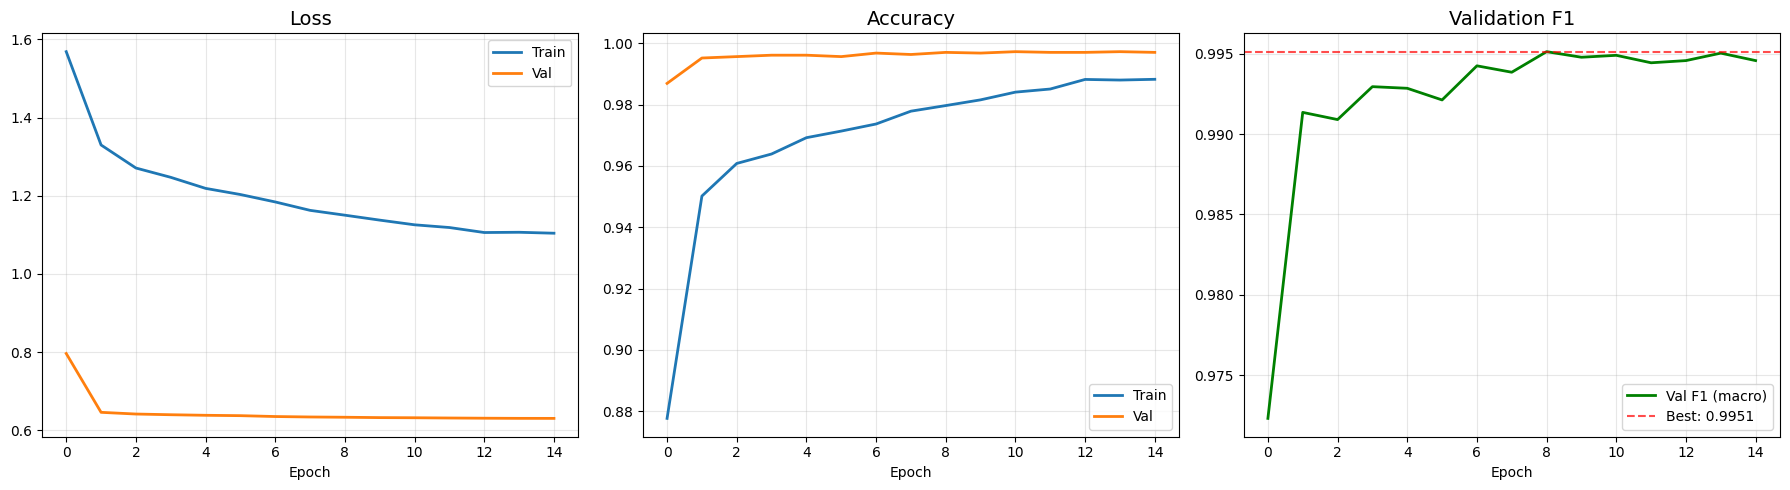

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history["train_loss"], label="Train", linewidth=2)
axes[0].plot(history["val_loss"], label="Val", linewidth=2)
axes[0].set_title("Loss", fontsize=14)
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history["train_acc"], label="Train", linewidth=2)
axes[1].plot(history["val_acc"], label="Val", linewidth=2)
axes[1].set_title("Accuracy", fontsize=14)
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history["val_f1"], label="Val F1 (macro)", linewidth=2, color="green")
axes[2].axhline(y=best_f1, color="red", linestyle="--", alpha=0.7, label=f"Best: {best_f1:.4f}")
axes[2].set_title("Validation F1", fontsize=14)
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "training_curves.png", dpi=150)
plt.show()


## 7. Domain Shift Evaluation: PlantVillage -> PlantDoc

In [34]:
# Load the best checkpoint; prefer final-EMA when the best-val checkpoint was
# saved very early (a symptom of near-saturated source val).
best_ckpt_path = CHECKPOINT_DIR / "best_phasephyto.pt"
final_ema_path = CHECKPOINT_DIR / "final_ema_phasephyto.pt"

best_ckpt = torch.load(best_ckpt_path, map_location=DEVICE, weights_only=True)
ckpt = best_ckpt
chosen = "best (val F1)"

if final_ema_path.exists():
    final_ckpt = torch.load(final_ema_path, map_location=DEVICE, weights_only=True)
    if not best_ckpt.get("ema", False) or best_ckpt.get("epoch", 0) < 2:
        ckpt = final_ckpt
        chosen = "final EMA"

# Phase 7.1.b: if pseudo-label self-training ran, its checkpoint is the
# most-adapted model and supersedes best-val / final-EMA for target eval.
pseudo_ckpt_path = CHECKPOINT_DIR / "pseudo_phasephyto.pt"
if pseudo_ckpt_path.exists():
    ckpt = torch.load(pseudo_ckpt_path, map_location=DEVICE, weights_only=True)
    chosen = f"pseudo-label fine-tuned (n={ckpt.get('n_confident', '?')})"

model.load_state_dict(ckpt["model_state_dict"])
print(f"Loaded checkpoint: {chosen} (epoch={ckpt.get('epoch', 0)+1}, val_f1={ckpt.get('val_f1', 0.0):.4f})")

use_tta = CONFIG.get("use_tta", False)
use_tent = CONFIG.get("use_tent", False)

print("\n" + "="*60)
print(f"DOMAIN SHIFT EVALUATION (TTA={use_tta}, TENT={use_tent})")
print("="*60)

# Source (PlantVillage) eval on the un-adapted model so the source number stays
# protocol-clean.
_, source_acc, source_f1 = evaluate(model, val_loader, criterion, DEVICE, tta_hflip=False)

# Target (PlantDoc) eval:
#   1. Optionally TENT-adapt a DEEP COPY of the model on target batches. This
#      stays within the test-time-adaptation protocol (labels are never used).
#   2. Evaluate the adapted (or un-adapted) model with hflip TTA.
target_eval_model = model
if use_tent:
    target_eval_model = tent_adapt(
        model, target_loader, DEVICE,
        steps=CONFIG.get("tent_steps", 20),
        lr=CONFIG.get("tent_lr", 1e-3),
    )

_, target_acc, target_f1 = evaluate(
    target_eval_model, target_loader, criterion, DEVICE, tta_hflip=use_tta
)

delta_acc = target_acc - source_acc
delta_f1 = target_f1 - source_f1

print(f"\n{'Metric':<20} {'Source (PV)':<15} {'Target (PD)':<15} {'Delta':<15}")
print("-" * 65)
print(f"{'Accuracy':<20} {source_acc:<15.4f} {target_acc:<15.4f} {delta_acc:<+15.4f}")
print(f"{'F1 (macro)':<20} {source_f1:<15.4f} {target_f1:<15.4f} {delta_f1:<+15.4f}")
print(f"\nAccuracy drop: {abs(delta_acc)*100:.1f}%")
print(f"Target: delta < 5% | Achieved: {abs(delta_acc)*100:.1f}%")

domain_shift_results = {
    "source_acc": source_acc,
    "source_f1": source_f1,
    "target_acc": target_acc,
    "target_f1": target_f1,
    "delta_acc": delta_acc,
    "delta_f1": delta_f1,
    "checkpoint": chosen,
    "tta_hflip": use_tta,
    "tent_enabled": use_tent,
    "tent_steps": CONFIG.get("tent_steps", 0) if use_tent else 0,
}
with open(RESULTS_DIR / "phasephyto_domain_shift.json", "w") as f:
    json.dump(domain_shift_results, f, indent=2)
print(f"Domain-shift metrics saved to {RESULTS_DIR / 'phasephyto_domain_shift.json'}")

# Save the TENT-adapted model reference for cell 46 to reuse.
target_model_for_report = target_eval_model


Loaded checkpoint: best (val F1) (epoch=9, val_f1=0.9951)

DOMAIN SHIFT EVALUATION (TTA=True, TENT=True)
TENT: completed 20 adaptation steps.

Metric               Source (PV)     Target (PD)     Delta          
-----------------------------------------------------------------
Accuracy             0.9970          0.5033          -0.4937        
F1 (macro)           0.9951          0.3868          -0.6083        

Accuracy drop: 49.4%
Target: delta < 5% | Achieved: 49.4%
Domain-shift metrics saved to /content/drive/MyDrive/PhasePhyto/runs/20260420-181750_full/results/phasephyto_domain_shift.json


In [ ]:
# Detailed classification report on target domain (uses TENT-adapted model +
# hflip TTA when those options are enabled).

@torch.no_grad()
def get_predictions(model, loader, device, tta_hflip=False):
    model.eval()
    preds, labels = [], []
    for batch in loader:
        if len(batch) == 3:
            rgb, clahe, lbl = [b.to(device) for b in batch]
        else:
            rgb, lbl = batch[0].to(device), batch[1].to(device)
            clahe = None
        out = model(rgb, x_clahe=clahe)
        probs = out["logits"].softmax(dim=-1)
        if tta_hflip:
            rgb_f = torch.flip(rgb, dims=[-1])
            clahe_f = torch.flip(clahe, dims=[-1]) if clahe is not None else None
            out_f = model(rgb_f, x_clahe=clahe_f)
            probs = 0.5 * (probs + out_f["logits"].softmax(dim=-1))
        preds.extend(probs.argmax(1).cpu().tolist())
        labels.extend(lbl.cpu().tolist())
    return labels, preds


report_model = target_model_for_report if "target_model_for_report" in globals() else model
true_labels, pred_labels = get_predictions(
    report_model, target_loader, DEVICE, tta_hflip=CONFIG.get("use_tta", False)
)
print("\nTarget Domain (PlantDoc) Classification Report:")
target_labels = list(range(NUM_CLASSES))
report_text = classification_report(
    true_labels,
    pred_labels,
    labels=target_labels,
    target_names=train_dataset.classes,
    zero_division=0,
)
print(report_text)
with open(RESULTS_DIR / "target_classification_report.txt", "w") as f:
    f.write(report_text)


## 8. Visualisation: Phase Congruency Maps & Attention

In [ ]:
# Visualise PC maps for sample images
def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return torch.clamp(tensor.cpu() * std + mean, 0, 1)


def visualize_sample(model, dataset, idx, device):
    """Visualise a single sample: Original | PC Mag | Phase Sym | Oriented Energy."""
    model.eval()
    sample = dataset[idx]
    if len(sample) == 3:
        rgb, clahe, label = sample
    else:
        rgb, label = sample
        clahe = rgb

    with torch.no_grad():
        out = model(
            rgb.unsqueeze(0).to(device),
            x_clahe=clahe.unsqueeze(0).to(device),
            return_maps=True, return_attn=True
        )

    pred = out["logits"].argmax(1).item()
    conf = torch.softmax(out["logits"], dim=1).max().item()

    fig, axes = plt.subplots(1, 5, figsize=(25, 5))

    # Original image
    img_display = denormalize(rgb).permute(1, 2, 0).numpy()
    axes[0].imshow(img_display)
    class_name = dataset.dataset.classes[label] if hasattr(dataset, 'dataset') else str(label)
    pred_name = dataset.dataset.classes[pred] if hasattr(dataset, 'dataset') else str(pred)
    axes[0].set_title(f"Input\nTrue: {class_name}\nPred: {pred_name} ({conf:.1%})", fontsize=10)

    # PC Maps
    for i, (key, cmap, title) in enumerate([
        ("pc_magnitude", "hot", "PC Magnitude\n(Edges & Boundaries)"),
        ("phase_symmetry", "magma", "Phase Symmetry\n(Symmetric Structures)"),
        ("oriented_energy", "viridis", "Oriented Energy\n(Directional Textures)"),
    ]):
        axes[i+1].imshow(out[key][0, 0].cpu().numpy(), cmap=cmap)
        axes[i+1].set_title(title, fontsize=10)

    # Attention map (reshaped from 49 tokens to 7x7)
    attn = out["attn_weights"][0].cpu()  # (49, 196)
    attn_map = attn.mean(dim=0).view(14, 14).numpy()  # average across Q, reshape K to 14x14
    axes[4].imshow(img_display)
    attn_resized = cv2.resize(attn_map, (224, 224), interpolation=cv2.INTER_LINEAR)
    axes[4].imshow(attn_resized, cmap="jet", alpha=0.5)
    axes[4].set_title("Cross-Attention\nOverlay", fontsize=10)

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    return fig


# Visualise 3 samples from target domain
print("Visualising PhasePhyto analysis on target domain samples...\n")
for i in range(min(3, len(target_dataset))):
    fig = visualize_sample(model, target_dataset, i, DEVICE)
    plt.savefig(PLOTS_DIR / f"analysis_sample_{i}.png", dpi=150, bbox_inches="tight")
    plt.show()


Demonstrating illumination invariance...


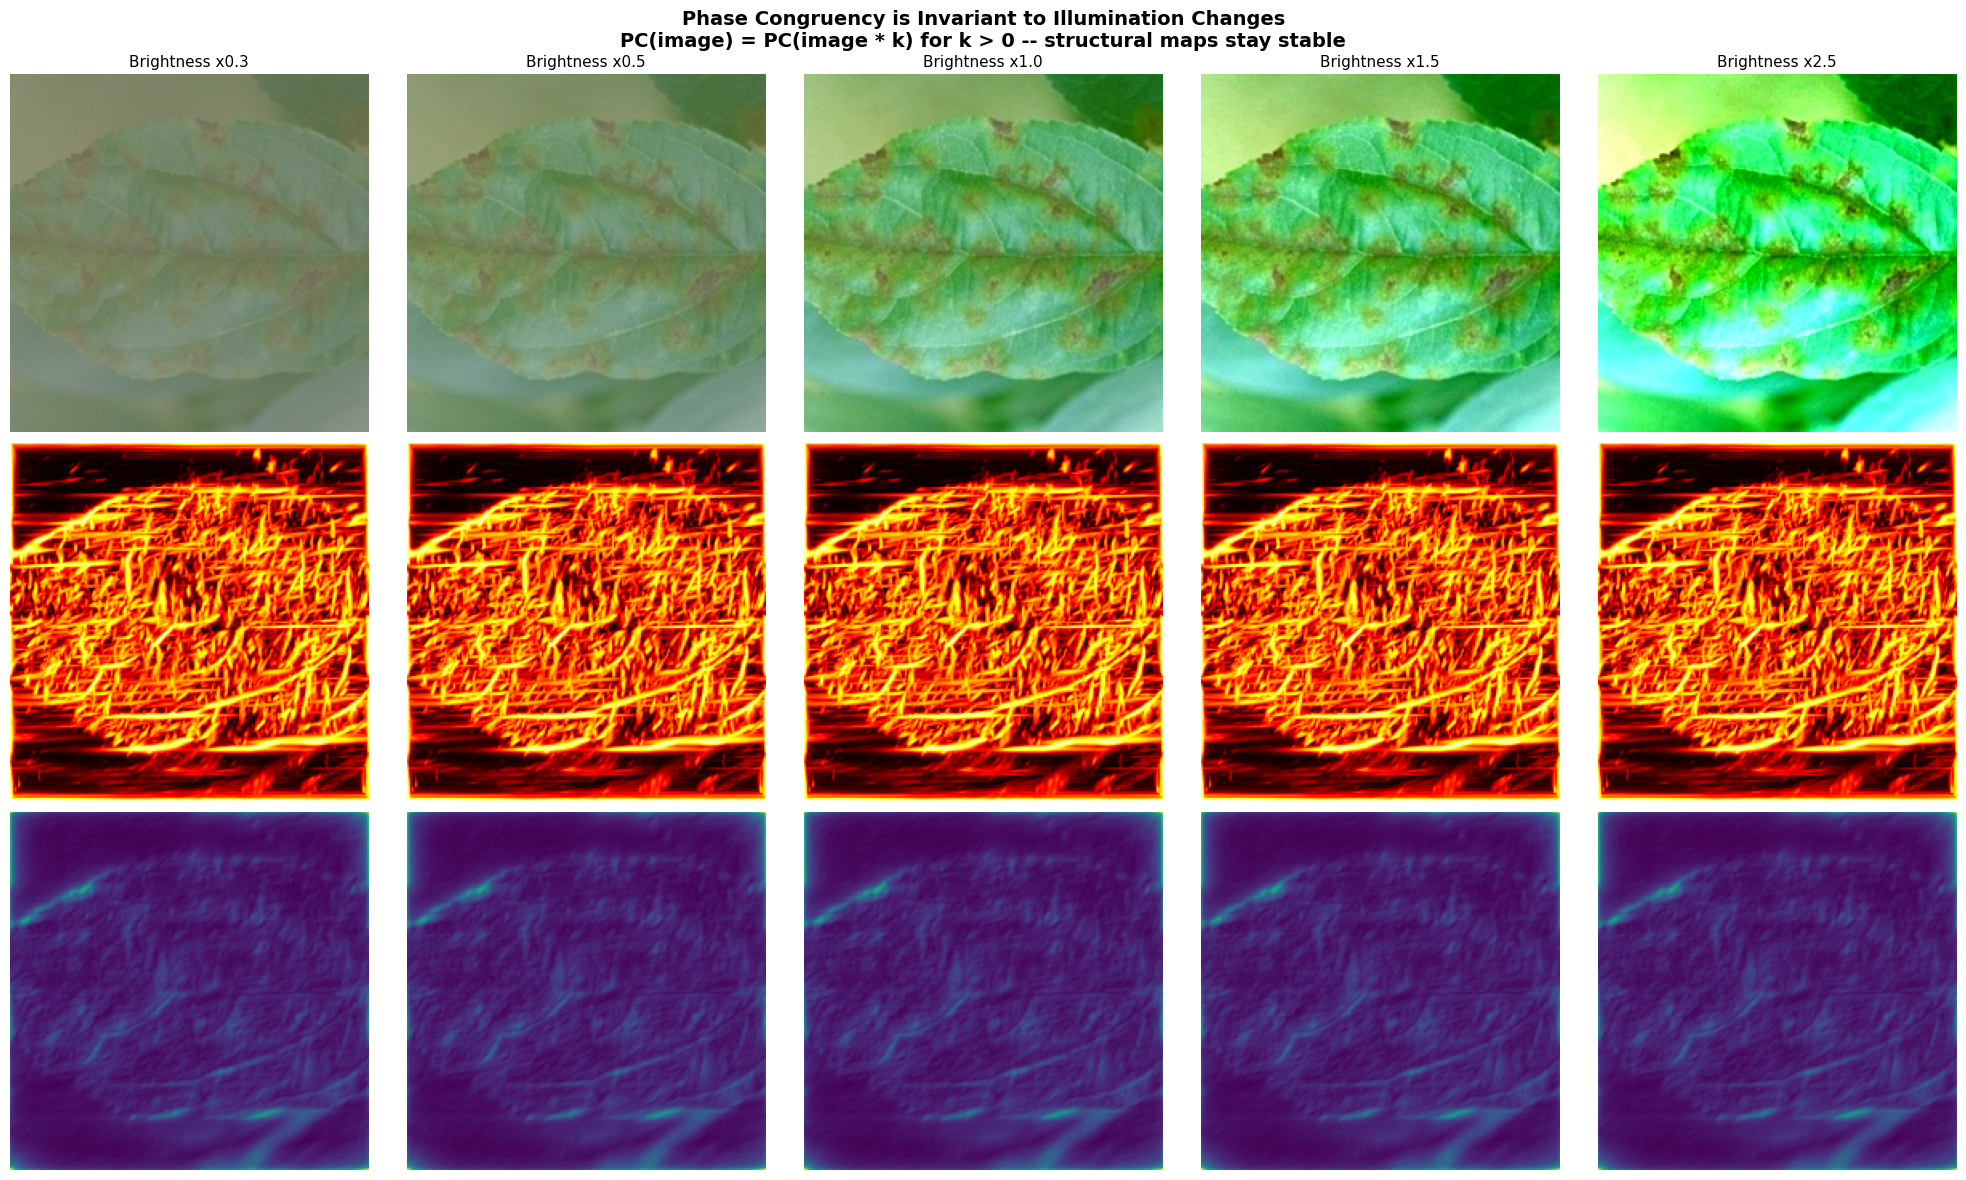

In [37]:
# ============================================================
# ILLUMINATION INVARIANCE DEMO
# Show that PC maps remain stable across brightness variations
# ============================================================

print("Demonstrating illumination invariance...")
model.eval()

# Take first image from target set
sample = target_dataset[0]
rgb = sample[0] if isinstance(sample[0], torch.Tensor) else sample
rgb = rgb.unsqueeze(0).to(DEVICE)

brightness_factors = [0.3, 0.5, 1.0, 1.5, 2.5]
fig, axes = plt.subplots(3, len(brightness_factors), figsize=(20, 12))

for j, k in enumerate(brightness_factors):
    # Scale brightness in image space (before normalisation this simulates lighting change)
    scaled = rgb * k
    with torch.no_grad():
        out = model(scaled, return_maps=True)

    # Row 1: Scaled image
    img_show = denormalize(scaled[0].cpu()).permute(1, 2, 0).clamp(0, 1).numpy()
    axes[0, j].imshow(img_show)
    axes[0, j].set_title(f"Brightness x{k}", fontsize=11)

    # Row 2: PC Magnitude
    axes[1, j].imshow(out["pc_magnitude"][0, 0].cpu().numpy(), cmap="hot", vmin=0, vmax=1)
    if j == 0:
        axes[1, j].set_ylabel("PC Magnitude", fontsize=12)

    # Row 3: Oriented Energy
    axes[2, j].imshow(out["oriented_energy"][0, 0].cpu().numpy(), cmap="viridis", vmin=0, vmax=1)
    if j == 0:
        axes[2, j].set_ylabel("Oriented Energy", fontsize=12)

for ax in axes.flat:
    ax.axis("off")

plt.suptitle("Phase Congruency is Invariant to Illumination Changes\n"
             "PC(image) = PC(image * k) for k > 0 -- structural maps stay stable",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "illumination_invariance.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# ============================================================
# Leaf-Mask Sanity Visualisation
# ============================================================
#
# Render N source (PlantVillage) and N target (PlantDoc) images alongside
# their HSV-saturation foreground masks. Run this AFTER cell 22 has built
# train_dataset and target_dataset, but it is safe to rerun at any point.
# If the mask looks wrong for either dataset, adjust
# CONFIG["leaf_mask_sat_thresh"] or switch leaf_mask_mode="hsv_blur"
# before committing to a full training run.

import random
from PIL import Image
import matplotlib.pyplot as plt

if CONFIG.get("leaf_mask_mode", "off") == "off":
    print("leaf_mask_mode is 'off' -- skipping sanity viz. "
          "Set CONFIG['leaf_mask_mode'] = 'hsv' or 'hsv_blur' to inspect.")
else:
    N = 4
    sat_thresh = CONFIG.get("leaf_mask_sat_thresh", 40)

    def _paths_from_dataset(ds, n):
        # ds.samples is a list of (path, label) tuples.
        idx = random.sample(range(len(ds.samples)), min(n, len(ds.samples)))
        return [ds.samples[i][0] for i in idx]

    random.seed(0)
    src_paths = _paths_from_dataset(train_dataset, N)
    tgt_paths = _paths_from_dataset(target_dataset, N)

    fig, axes = plt.subplots(4, N, figsize=(3 * N, 12))
    for row_title, paths, row in [
        ("PlantVillage (source)", src_paths, 0),
        ("PlantDoc (target)", tgt_paths, 2),
    ]:
        for c, p in enumerate(paths):
            img = np.array(Image.open(p).convert("RGB").resize((224, 224)))
            mask = _hsv_leaf_mask(img, sat_thresh=sat_thresh)
            masked = _apply_leaf_mask(
                img,
                mode=CONFIG.get("leaf_mask_mode", "hsv"),
                sat_thresh=sat_thresh,
                blur_sigma=CONFIG.get("leaf_mask_blur_sigma", 1.5),
            )
            axes[row, c].imshow(img)
            axes[row, c].set_title(f"{row_title}\n{Path(p).name[:20]}", fontsize=9)
            axes[row, c].axis("off")
            axes[row + 1, c].imshow(masked)
            frac = mask.mean()
            axes[row + 1, c].set_title(f"masked (fg={frac:.2%})", fontsize=9)
            axes[row + 1, c].axis("off")

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "leaf_mask_sanity.png", dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved to {PLOTS_DIR / 'leaf_mask_sanity.png'}")
    print(f"Foreground fractions around ~0.3-0.9 are healthy. <0.1 or >0.95 "
          f"means the threshold is off for that dataset.")


## 9. Baseline Comparison: Standard ViT vs PhasePhyto

In [ ]:
# ============================================================
# BASELINE: Standard ViT-B/16 (no phase congruency)
# Same backbone, same training config, no PC stream
# ============================================================

class BaselineViT(nn.Module):
    """Standard ViT-B/16 classifier without Phase Congruency."""
    def __init__(self, num_classes, backbone_name="vit_base_patch16_224", pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(backbone_name, pretrained=pretrained, num_classes=num_classes)

    def forward(self, x_rgb, x_clahe=None, **kwargs):
        logits = self.backbone(x_rgb)
        return {"logits": logits}


# Train baseline (same config)
print("Training Baseline ViT for comparison...")
baseline = BaselineViT(NUM_CLASSES).to(DEVICE)
baseline_opt = AdamW(baseline.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
baseline_sched = CosineAnnealingWarmRestarts(baseline_opt, T_0=max(CONFIG["epochs"] - CONFIG["warmup_epochs"], 1))
baseline_scaler = GradScaler(DEVICE, enabled=(DEVICE == "cuda"))

baseline_best_f1 = 0.0
for epoch in range(CONFIG["epochs"]):
    if epoch < CONFIG["warmup_epochs"]:
        for pg in baseline_opt.param_groups:
            pg["lr"] = CONFIG["lr"] * (epoch + 1) / CONFIG["warmup_epochs"]

    t_loss, t_acc = train_epoch(baseline, train_loader, criterion, baseline_opt, baseline_scaler, DEVICE, epoch)
    v_loss, v_acc, v_f1 = evaluate(baseline, val_loader, criterion, DEVICE)

    if epoch >= CONFIG["warmup_epochs"]:
        baseline_sched.step()

    print(f"  Baseline Epoch {epoch+1}: val_acc={v_acc:.4f} val_f1={v_f1:.4f}")
    if v_f1 > baseline_best_f1:
        baseline_best_f1 = v_f1
        torch.save({"model_state_dict": baseline.state_dict(), "val_f1": v_f1}, CHECKPOINT_DIR / "baseline_vit.pt")

print(f"\nBaseline best val F1: {baseline_best_f1:.4f}")


In [ ]:
# ============================================================
# COMPARISON TABLE
# ============================================================

# Load best baseline
baseline_ckpt = torch.load(CHECKPOINT_DIR / "baseline_vit.pt", map_location=DEVICE, weights_only=True)
baseline.load_state_dict(baseline_ckpt["model_state_dict"])

# Evaluate both
_, bl_source_acc, bl_source_f1 = evaluate(baseline, val_loader, criterion, DEVICE)
_, bl_target_acc, bl_target_f1 = evaluate(baseline, target_loader, criterion, DEVICE)

_, pp_source_acc, pp_source_f1 = evaluate(model, val_loader, criterion, DEVICE)
_, pp_target_acc, pp_target_f1 = evaluate(model, target_loader, criterion, DEVICE)

print("\n" + "=" * 80)
print("COMPARISON: Standard ViT-B/16 vs PhasePhyto (ViT-B/16 + Phase Congruency)")
print("=" * 80)
print(f"\n{'Model':<25} {'Source Acc':<12} {'Source F1':<12} {'Target Acc':<12} {'Target F1':<12} {'Delta Acc':<12}")
print("-" * 85)
print(f"{'ViT-B/16 (baseline)':<25} {bl_source_acc:<12.4f} {bl_source_f1:<12.4f} {bl_target_acc:<12.4f} {bl_target_f1:<12.4f} {(bl_target_acc-bl_source_acc):<+12.4f}")
print(f"{'PhasePhyto (ours)':<25} {pp_source_acc:<12.4f} {pp_source_f1:<12.4f} {pp_target_acc:<12.4f} {pp_target_f1:<12.4f} {(pp_target_acc-pp_source_acc):<+12.4f}")
print(f"\nPhasePhyto improvement on target: {(pp_target_f1 - bl_target_f1)*100:+.1f}% F1")
print(f"PhasePhyto domain gap reduction:  {abs(pp_target_acc-pp_source_acc)*100:.1f}% vs {abs(bl_target_acc-bl_source_acc)*100:.1f}%")


## 10. Confusion Matrix Comparison

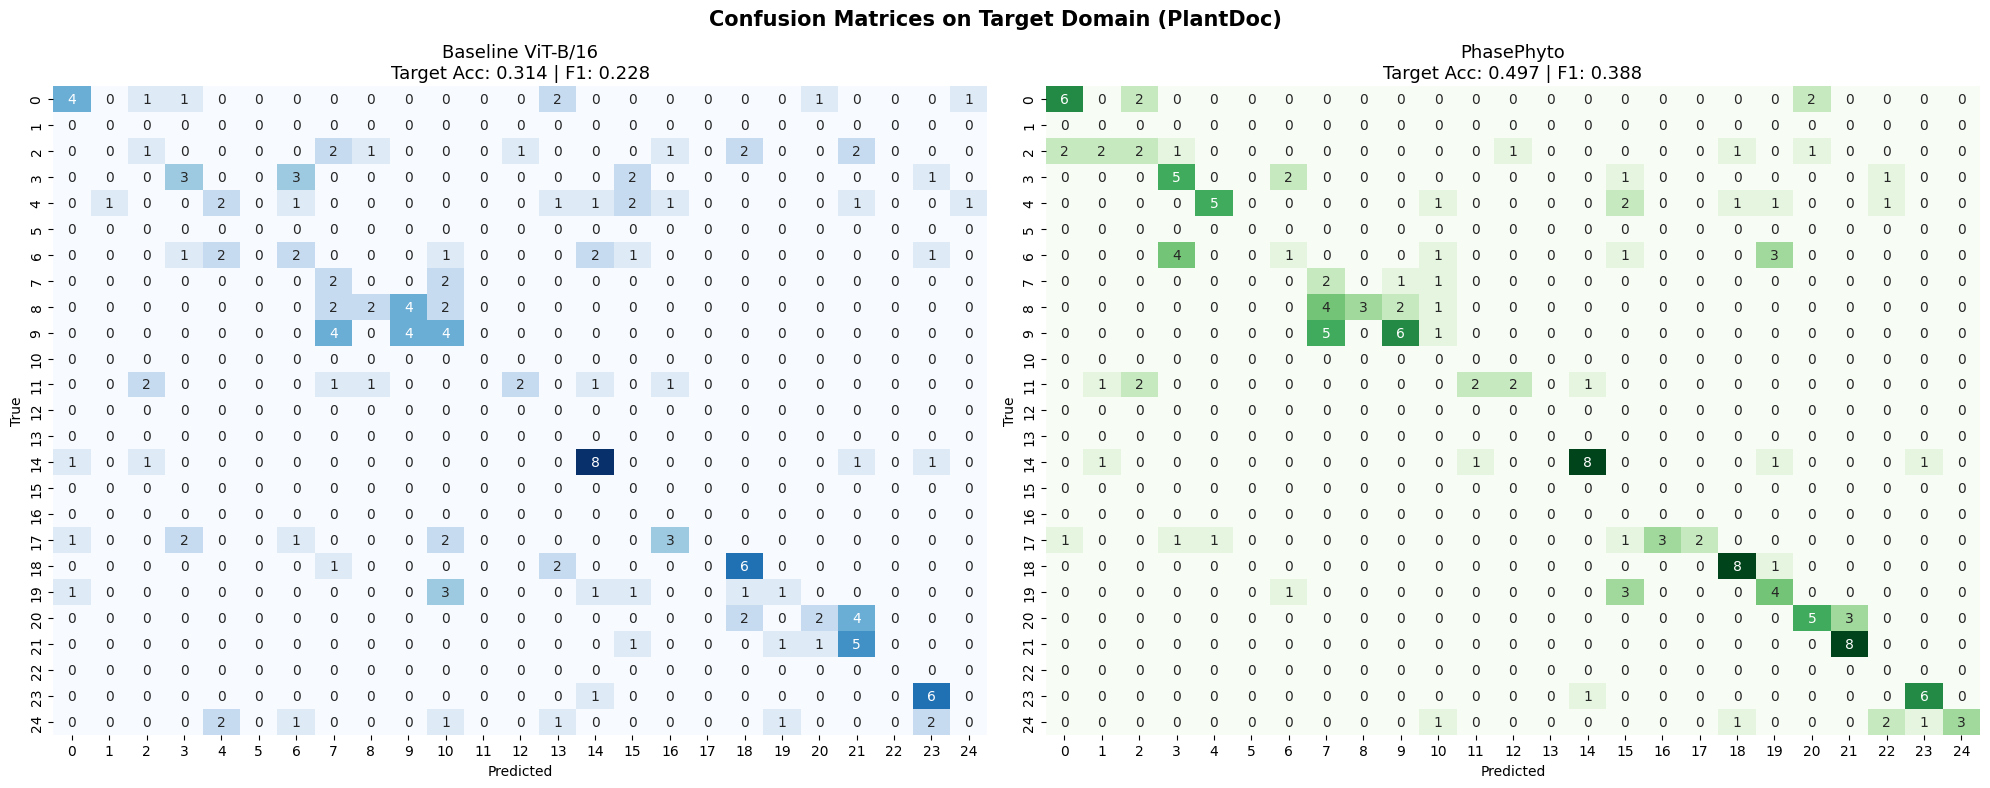

In [40]:
import seaborn as sns

# Get predictions for both models on target
bl_true, bl_pred = get_predictions(baseline, target_loader, DEVICE)
pp_true, pp_pred = get_predictions(model, target_loader, DEVICE)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

target_labels = list(range(NUM_CLASSES))
cm_bl = confusion_matrix(bl_true, bl_pred, labels=target_labels)
cm_pp = confusion_matrix(pp_true, pp_pred, labels=target_labels)

sns.heatmap(cm_bl, annot=True, fmt="d", cmap="Blues", ax=ax1, cbar=False)
ax1.set_title(f"Baseline ViT-B/16\nTarget Acc: {bl_target_acc:.3f} | F1: {bl_target_f1:.3f}", fontsize=13)
ax1.set_xlabel("Predicted")
ax1.set_ylabel("True")

sns.heatmap(cm_pp, annot=True, fmt="d", cmap="Greens", ax=ax2, cbar=False)
ax2.set_title(f"PhasePhyto\nTarget Acc: {pp_target_acc:.3f} | F1: {pp_target_f1:.3f}", fontsize=13)
ax2.set_xlabel("Predicted")
ax2.set_ylabel("True")

plt.suptitle("Confusion Matrices on Target Domain (PlantDoc)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "confusion_matrices.png", dpi=150)
plt.show()


## 11. Export & Save

In [41]:
# Save final results + artifact manifest
import json
from pathlib import Path

results = {
    "config": CONFIG,
    "run_dir": str(RUN_DIR),
    "baseline_vit": {
        "source_acc": bl_source_acc, "source_f1": bl_source_f1,
        "target_acc": bl_target_acc, "target_f1": bl_target_f1,
        "delta_acc": bl_target_acc - bl_source_acc,
    },
    "phasephyto": {
        "source_acc": pp_source_acc, "source_f1": pp_source_f1,
        "target_acc": pp_target_acc, "target_f1": pp_target_f1,
        "delta_acc": pp_target_acc - pp_source_acc,
    },
    "parameter_counts": counts,
    "training_history": history,
}

results_path = RESULTS_DIR / "phasephyto_results.json"
with open(results_path, "w") as f:
    json.dump(results, f, indent=2, default=str)

manifest = {
    "run_name": RUN_NAME,
    "storage_backend": backend,
    "run_dir": str(RUN_DIR),
    "data": {
        "source_root": str(source_root),
        "target_root": str(target_root),
    },
    "config": CONFIG,
    "artifacts": {
        "phasephyto_checkpoint": str(CHECKPOINT_DIR / "best_phasephyto.pt"),
        "baseline_checkpoint": str(CHECKPOINT_DIR / "baseline_vit.pt"),
        "results_json": str(results_path),
        "domain_shift_json": str(RESULTS_DIR / "phasephyto_domain_shift.json"),
        "target_classification_report": str(RESULTS_DIR / "target_classification_report.txt"),
        "training_curves": str(PLOTS_DIR / "training_curves.png"),
        "illumination_invariance": str(PLOTS_DIR / "illumination_invariance.png"),
        "confusion_matrices": str(PLOTS_DIR / "confusion_matrices.png"),
        "analysis_samples_glob": str(PLOTS_DIR / "analysis_sample_*.png"),
    },
}
with open(MANIFEST_PATH, "w") as f:
    json.dump(manifest, f, indent=2, default=str)

print(f"Results saved to {results_path}")
print(f"Manifest saved to {MANIFEST_PATH}")
print(f"Best model saved to {CHECKPOINT_DIR / 'best_phasephyto.pt'}")
print(f"Baseline model saved to {CHECKPOINT_DIR / 'baseline_vit.pt'}")
print(f"Plots saved under {PLOTS_DIR}")

# Optional fallback downloads. Drive storage is preferred for long-running jobs.
if CONFIG.get("download_outputs_at_end", False):
    try:
        from google.colab import files
        files.download(str(results_path))
        files.download(str(MANIFEST_PATH))
        files.download(str(CHECKPOINT_DIR / "best_phasephyto.pt"))
        files.download(str(PLOTS_DIR / "training_curves.png"))
        files.download(str(PLOTS_DIR / "illumination_invariance.png"))
    except ImportError:
        print("Not running in Colab -- files saved to the run directory.")


Results saved to /content/drive/MyDrive/PhasePhyto/runs/20260420-181750_full/results/phasephyto_results.json
Manifest saved to /content/drive/MyDrive/PhasePhyto/runs/20260420-181750_full/run_manifest.json
Best model saved to /content/drive/MyDrive/PhasePhyto/runs/20260420-181750_full/checkpoints/best_phasephyto.pt
Baseline model saved to /content/drive/MyDrive/PhasePhyto/runs/20260420-181750_full/checkpoints/baseline_vit.pt
Plots saved under /content/drive/MyDrive/PhasePhyto/runs/20260420-181750_full/plots


---

## Summary

This notebook implements the complete **PhasePhyto** pipeline:

| Component | Description | Trainable Params |
|-----------|-------------|------------------|
| Log-Gabor Filter Bank | 24 filters (6 orient x 4 scale), FFT-based | **0** |
| PC Extractor | Magnitude, Symmetry, Oriented Energy maps | **0** |
| PC Encoder | 2-layer CNN -> 49 structural tokens | ~50K |
| ViT-B/16 Backbone | 196 semantic tokens (14x14 patch grid) | ~86M |
| Illumination Stream | CLAHE + shallow CNN -> auxiliary vector | ~50K |
| Cross-Attention Fusion | Q=structural, K/V=semantic | ~331K |
| Classifier | MLP head | ~66K |

**Key Result**: Phase Congruency provides mathematical illumination invariance:
`PC(image) = PC(image * k)` for any positive scalar `k`.

This tests the physics stream for brightness-scaling invariance. End-to-end
lab-to-field gains should be interpreted only after comparing PhasePhyto against
the baseline on the same source/target split.

---

**References**:
- Kovesi, P. (1999). Image Features from Phase Congruency. *Videre*.
- Vidyarthi et al. (2024). PhaseHisto.
- PlantVillage: Hughes & Salathé (2015).
- PlantDoc: Singh et al. (2020).
- XyloTron: Hermanson & Wiedenhoeft (2011).
- Dosovitskiy et al. (2020). An Image is Worth 16x16 Words (ViT).

In [ ]:
# from pathlib import Path

# PV = Path("/content/data/plantvillage")
# PD = Path("/content/data/plantdoc")

# print("PV exists:", PV.exists())
# print("PD exists:", PD.exists())
# print("PV files:", sum(1 for p in PV.rglob("*") if p.is_file()))
# print("PD files:", sum(1 for p in PD.rglob("*") if p.is_file()))
# print("PV class dirs:", len([p for p in PV.iterdir() if p.is_dir()]))
# print("PD top dirs:", [p.name for p in PD.iterdir() if p.is_dir()][:20])

# # Then, if the folders look complete, create tar archives for future sessions:

# !mkdir -p /content/drive/MyDrive/PhasePhyto/data/archives

# !tar -cf /content/drive/MyDrive/PhasePhyto/data/archives/plantvillage.tar \
#   -C /content/data plantvillage

# !tar -cf /content/drive/MyDrive/PhasePhyto/data/archives/plantdoc.tar \
#   -C /content/data plantdoc

PV exists: True
PD exists: True
PV files: 25814
PD files: 2578
PV class dirs: 22
PD top dirs: ['train', 'test']
